In [1]:
import matplotlib.pyplot as pl
import numpy as np
import ot
from ot.gromov import gromov_wasserstein, fused_gromov_wasserstein

/home/eungyeop/anaconda3/envs/project/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
n = 20 
n2 = 30 
sig = 1 
sig2 = 0.1 

np.random.seed(0)

phi = np.arange(n)[:, None]
xs = phi + sig * np.random.randn(n, 1)
ys = np.vstack(
    (np.ones((n // 2, 1)), 0 * np.ones((n // 2, 1)))
) + sig2 * np.random.randn(n, 1)

phi2 = np.arange(n2)[:, None]
xt = phi2 + sig * np.random.randn(n2, 1)
yt = np.vstack(
    (np.ones((n2 // 2, 1)), 0 * np.ones((n2 // 2, 1)))
) + sig2 * np.random.randn(n2, 1)

yt = yt[::-1, :]
p = ot.unif(n)
q = ot.unif(n2)


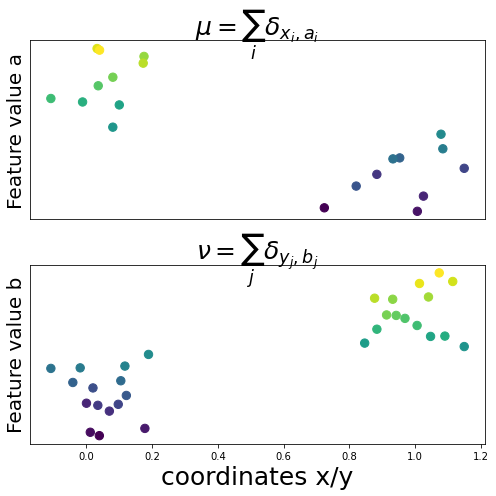

In [3]:
pl.figure(1, (7, 7))

pl.subplot(2, 1, 1)

pl.scatter(ys, xs, c=phi, s=70)
pl.ylabel("Feature value a", fontsize=20)
pl.title("$\mu=\sum_i \delta_{x_i,a_i}$", fontsize=25, y=1)
pl.xticks(())
pl.yticks(())
pl.subplot(2, 1, 2)
pl.scatter(yt, xt, c=phi2, s=70)
pl.xlabel("coordinates x/y", fontsize=25)
pl.ylabel("Feature value b", fontsize=20)
pl.title("$\\nu=\sum_j \delta_{y_j,b_j}$", fontsize=25, y=1)
pl.yticks(())
pl.tight_layout()
pl.show()

In [4]:
C1 = ot.dist(xs)
C2 = ot.dist(xt)
M = ot.dist(ys, yt)
w1 = ot.unif(C1.shape[0])
w2 = ot.unif(C2.shape[0])
Got = ot.emd([], [], M)

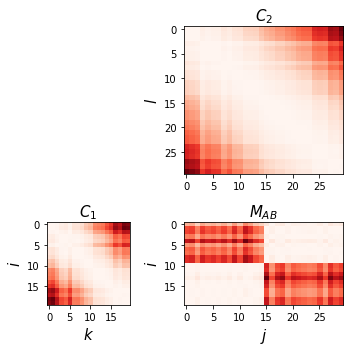

In [5]:
cmap = "Reds"

pl.figure(2, (5, 5))
fs = 15
l_x = [0, 5, 10, 15]
l_y = [0, 5, 10, 15, 20, 25]
gs = pl.GridSpec(5, 5)

ax1 = pl.subplot(gs[3:, :2])

pl.imshow(C1, cmap=cmap, interpolation="nearest")
pl.title("$C_1$", fontsize=fs)
pl.xlabel("$k$", fontsize=fs)
pl.ylabel("$i$", fontsize=fs)
pl.xticks(l_x)
pl.yticks(l_x)

ax2 = pl.subplot(gs[:3, 2:])

pl.imshow(C2, cmap=cmap, interpolation="nearest")
pl.title("$C_2$", fontsize=fs)
pl.ylabel("$l$", fontsize=fs)
pl.xticks(())
pl.yticks(l_y)
ax2.set_aspect("auto")

ax3 = pl.subplot(gs[3:, 2:], sharex=ax2, sharey=ax1)
pl.imshow(M, cmap=cmap, interpolation="nearest")
pl.yticks(l_x)
pl.xticks(l_y)
pl.ylabel("$i$", fontsize=fs)
pl.title("$M_{AB}$", fontsize=fs)
pl.xlabel("$j$", fontsize=fs)
pl.tight_layout()
ax3.set_aspect("auto")
pl.show()

In [6]:
alpha = 1e-3

ot.tic()
Gwg, logw = fused_gromov_wasserstein(
    M, C1, C2, p, q, loss_fun="square_loss", alpha=alpha, verbose=True, log=True
)
ot.toc()

# reload_ext WGW
Gg, log = gromov_wasserstein(
    C1, C2, p, q, loss_fun="square_loss", verbose=True, log=True
)

It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.734412e+01|0.000000e+00|0.000000e+00
    1|2.508254e+01|8.875326e-01|2.226158e+01
    2|2.189327e+01|1.456740e-01|3.189279e+00
    3|2.189327e+01|1.622743e-16|3.552714e-15
Elapsed time : 0.002997159957885742 s
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.683978e+04|0.000000e+00|0.000000e+00
    1|3.860061e+04|2.134468e-01|8.239175e+03
    2|2.182948e+04|7.682787e-01|1.677113e+04
    3|2.182948e+04|0.000000e+00|0.000000e+00


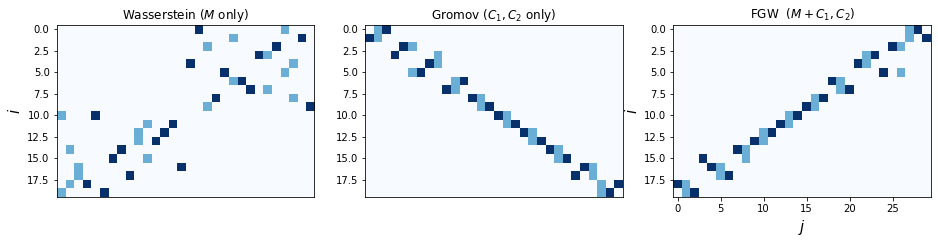

In [7]:
# visu OT matrix
cmap = "Blues"
fs = 15
pl.figure(3, (13, 5))
pl.clf()
pl.subplot(1, 3, 1)
pl.imshow(Got, cmap=cmap, interpolation="nearest")
pl.ylabel("$i$", fontsize=fs)
pl.xticks(())

pl.title("Wasserstein ($M$ only)")

pl.subplot(1, 3, 2)
pl.imshow(Gg, cmap=cmap, interpolation="nearest")
pl.title("Gromov ($C_1,C_2$ only)")
pl.xticks(())
pl.subplot(1, 3, 3)
pl.imshow(Gwg, cmap=cmap, interpolation="nearest")
pl.title("FGW  ($M+C_1,C_2$)")

pl.xlabel("$j$", fontsize=fs)
pl.ylabel("$i$", fontsize=fs)

pl.tight_layout()
pl.show()

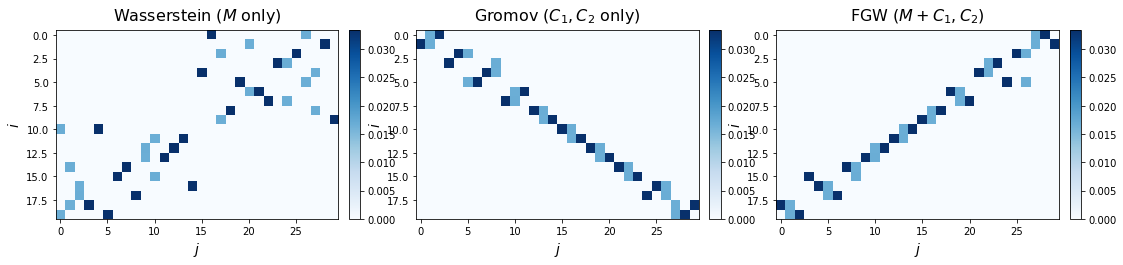

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np

def plot_plan(ax, matrix, title):
    im = ax.imshow(matrix, cmap="Blues", interpolation="nearest")
    ax.set_title(title, fontsize=16, pad=10)
    ax.set_xlabel("$j$", fontsize=14)
    ax.set_ylabel("$i$", fontsize=14)

    # --- Colorbar aligned cleanly ---
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.15)
    cb = plt.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=10)

    return ax


# --- Main figure layout ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

plot_plan(axes[0], Got, "Wasserstein ($M$ only)")
plot_plan(axes[1], Gg, "Gromov ($C_1, C_2$ only)")
plot_plan(axes[2], Gwg, "FGW ($M + C_1, C_2$)")

plt.show()


### Pytorch FGW

In [9]:
import torch 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns
import matplotlib.collections as mc

In [10]:
import torch
import matplotlib.pyplot as plt
import matplotlib.collections as mc
import numpy as np
import seaborn as sns

class FGWSolver:
    """
    PyTorch implementation of Entropic Fused Gromov-Wasserstein.
    (Solving logic remains same as previous verified version)
    """
    @staticmethod
    def sinkhorn(C, a, b, epsilon=1e-2, num_iter=100):
        K = torch.exp(-C / epsilon)
        u = torch.ones_like(a)
        v = torch.ones_like(b)
        
        for _ in range(num_iter):
            Kv = torch.matmul(K, v.unsqueeze(-1)).squeeze(-1)
            u = a / (Kv + 1e-8)
            KTu = torch.matmul(K.transpose(-1, -2), u.unsqueeze(-1)).squeeze(-1)
            v = b / (KTu + 1e-8)
            
        Pi = u.unsqueeze(-1) * K * v.unsqueeze(-2)
        return Pi

    @staticmethod
    def gw_cost(C1, C2, Pi):
        mu = Pi.sum(dim=-1, keepdim=True)
        nu = Pi.sum(dim=-2, keepdim=True)
        
        term1 = torch.matmul(C1**2, mu)
        term2 = torch.matmul(C2**2, nu.transpose(-1, -2)).transpose(-1, -2)
        term3 = -2 * torch.matmul(torch.matmul(C1, Pi), C2.transpose(-1, -2))
        
        return term1 + term2 + term3

    @staticmethod
    def fgw(M, C1, C2, a, b, alpha=0.5, epsilon=0.05, num_iter=50):
        Pi = torch.matmul(a.unsqueeze(-1), b.unsqueeze(-2))
        C_total = None
        
        for i in range(num_iter):
            C_gw = FGWSolver.gw_cost(C1, C2, Pi)
            C_total = (1 - alpha) * M + alpha * C_gw
            Pi = FGWSolver.sinkhorn(C_total, a, b, epsilon=epsilon, num_iter=100)
            
        return Pi, C_total


        
class FGWVisualizer:
    @staticmethod
    def plot_matrices(C1, C2, M, title_prefix=""):
        """C1, C2, M 행렬 시각화 (1x3)"""
        C1 = C1.squeeze().cpu().numpy()
        C2 = C2.squeeze().cpu().numpy()
        M = M.squeeze().cpu().numpy()
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        sns.heatmap(C1, ax=axes[0], cmap='Blues', square=True, cbar=True)
        axes[0].set_title(f"{title_prefix} C1 (Source Structure)")
        
        sns.heatmap(C2, ax=axes[1], cmap='Blues', square=True, cbar=True)
        axes[1].set_title(f"{title_prefix} C2 (Target Structure)")
        
        sns.heatmap(M, ax=axes[2], cmap='Blues', square=True, cbar=True)
        axes[2].set_title(f"{title_prefix} M (Feature Cost)")
        
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_plans(Pi_W, Pi_GW, Pi_FGW):
        """Transport Plans 시각화 (1x3) - Wasserstein, Gromov, FGW 비교"""
        plans = [
            (Pi_W, "Wasserstein (Feature Only)"),
            (Pi_GW, "Gromov (Structure Only)"),
            (Pi_FGW, "Fused GW (Balanced)")
        ]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        for i, (pi, title) in enumerate(plans):
            pi_np = pi.squeeze().detach().cpu().numpy()
            sns.heatmap(pi_np, ax=axes[i], cmap='Blues', square=True, cbar=True)
            axes[i].set_title(title, fontsize=12, fontweight='bold')
            axes[i].set_xlabel("Target Nodes (K)")
            axes[i].set_ylabel("Source Nodes (N)")
            
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_graph_matching(xs, ys, xt, yt, Pi, title="Graph Matching"):
        """
        Source(원)와 Target(다이아몬드) 그래프 매칭 시각화 (인덱스 포함)
        """
        xs = xs.squeeze().cpu().numpy()
        ys = ys.squeeze().cpu().numpy()
        xt = xt.squeeze().cpu().numpy()
        yt = yt.squeeze().cpu().numpy()
        pi = Pi.squeeze().detach().cpu().numpy()

        x_shift = xs.max() - xt.min() + 3.0 
        xt_shifted = xt + x_shift

        plt.figure(figsize=(14, 7))
        ax = plt.gca()

        # 1. 연결선 그리기
        threshold = 1e-3 
        indices = np.argwhere(pi > threshold)
        
        lines = []
        colors = []
        linewidths = []

        for i, j in indices:
            p1 = (xs[i], ys[i])
            p2 = (xt_shifted[j], yt[j])
            lines.append([p1, p2])
            
            strength = pi[i, j] / pi.max()
            colors.append((0.2, 0.2, 0.2, strength * 0.8))
            linewidths.append(strength * 2.5)

        lc = mc.LineCollection(lines, colors=colors, linewidths=linewidths, zorder=1)
        ax.add_collection(lc)

        # 2. 노드 그리기 (Feature Value로 색칠)
        sc1 = plt.scatter(xs, ys, c=ys, cmap='coolwarm', s=150, edgecolors='k', linewidth=1.5,
                          marker='o', zorder=2, label='Source')
        sc2 = plt.scatter(xt_shifted, yt, c=yt, cmap='coolwarm', s=150, edgecolors='k', linewidth=1.5,
                          marker='D', zorder=2, label='Target')

        # ❗️ [추가] 각 노드에 인덱스 텍스트 추가
        text_offset_x = 0.5 # 노드 중심에서 텍스트가 떨어질 거리
        text_offset_y = 0.05 # 노드 중심에서 텍스트가 떨어질 거리 (y축)

        for i in range(len(xs)):
            ax.text(xs[i] + text_offset_x, ys[i] + text_offset_y, str(i), 
                    fontsize=8, ha='left', va='center', color='black', zorder=3)
        for i in range(len(xt_shifted)):
            ax.text(xt_shifted[i] + text_offset_x, yt[i] + text_offset_y, str(i), 
                    fontsize=8, ha='left', va='center', color='black', zorder=3)

        # 3. 텍스트 및 장식
        plt.title(title, fontsize=18, pad=20)
        
        plt.axis('off')

        plt.text(xs.mean(), ys.max() + 0.5, "Source Graph\n(Structure Only)", 
                 ha='center', va='bottom', fontsize=14, fontweight='bold')
        plt.text(xt_shifted.mean(), yt.max() + 0.5, "Target Graph\n(Structure Only)", 
                 ha='center', va='bottom', fontsize=14, fontweight='bold')

        cbar = plt.colorbar(sc1, label="Feature Value (Color)", pad=0.01, shrink=0.8)
        
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', label='Source Node',
                   markerfacecolor='lightgray', markeredgecolor='k', markersize=10),
            Line2D([0], [0], marker='D', color='w', label='Target Node',
                   markerfacecolor='lightgray', markeredgecolor='k', markersize=10)
        ]
        plt.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), 
                   ncol=2, frameon=False, fontsize=12)

        plt.tight_layout()
        plt.show()

In [11]:
def compare_plans(pi1, pi2, name1, name2):
    # (1, N, K) -> (N, K)
    p1 = pi1.squeeze()
    p2 = pi2.squeeze()
    
    # L1 Difference
    l1_diff = torch.sum(torch.abs(p1 - p2))
    
    # L-infinity Difference (Max difference at any point)
    max_diff = torch.max(torch.abs(p1 - p2))
    
    print(f"\nComparing {name1} vs {name2}:")
    print(f"  Sum of Absolute Differences (L1): {l1_diff.item():.4f}")
    print(f"  Max Absolute Difference (L-inf): {max_diff.item():.4f}")
    return l1_diff.item()

In [27]:
# --- 1. Generate Toy Data ---
torch.manual_seed(42)
n = 20
n2 = 10 # 매칭 보기 편하게 개수 동일하게 설정 (다르게 해도 됨)
sig = 1

# Structure (X coordinate)
phi = torch.arange(n, dtype=torch.float32).unsqueeze(1)
xs = phi + sig * torch.randn(n, 1)

phi2 = torch.arange(n2, dtype=torch.float32).unsqueeze(1)
xt = phi2 + sig * torch.randn(n2, 1)

# Features (Y value) - Reverse Pattern
# Source: High -> Low (Top to Bottom)
# Target: Low -> High (Bottom to Top)
ys = torch.linspace(1, 0, n).unsqueeze(1) + 0.1 * torch.randn(n, 1)
yt = torch.linspace(0, 1, n2).unsqueeze(1) + 0.1 * torch.randn(n2, 1)

# --- 2. Compute Matrices ---
# Structure Cost (Coordinate distance)
C1 = torch.cdist(xs, xs, p=2)**2
C2 = torch.cdist(xt, xt, p=2)**2

# Feature Cost (Value distance)
M = torch.cdist(ys, yt, p=2)**2

a = torch.ones(n) / n
b = torch.ones(n2) / n2

M_b, C1_b, C2_b = M.unsqueeze(0), C1.unsqueeze(0), C2.unsqueeze(0)
a_b, b_b = a.unsqueeze(0), b.unsqueeze(0)


In [28]:
# --- 3. Print Scales ---
print("--- Cost Matrix Scales (Max Values) ---")
print(f"Structure Cost (C1) Max: {C1.max().item():.4f}")
print(f"Structure Cost (C2) Max: {C2.max().item():.4f}")
print(f"Feature Cost (M) Max: {M.max().item():.4f}")

# Calculate and print the ratio
ratio = C1.max() / M.max()
print(f"\nScale Ratio (C1 / M): {ratio.item():.2f}")

--- Cost Matrix Scales (Max Values) ---
Structure Cost (C1) Max: 320.7298
Structure Cost (C2) Max: 90.7729
Feature Cost (M) Max: 1.2322

Scale Ratio (C1 / M): 260.29


>>> 1. Running Wasserstein Only (alpha=0) Feature : 1.0, Structure : 0.0 ...
>>> 2. Running Fused GW (alpha=0.3) Feature : 0.7, Structure : 0.3 ...
>>> 2. Running Fused GW (alpha=0.3) Feature : 0.7, Structure : 0.3 ...
>>> 3. Running Fused GW (alpha=0.5) Feature : 0.5, Structure : 0.5 ...
>>> 4. Running Fused GW (alpha=0.8) Feature : 0.8, Structure : 0.2 ...
>>> 5. Running Gromov Only (alpha=1) Feature : 0.0, Structure : 1.0 ...

--- [1] Transport Plans (Heatmaps) ---
>>> Comparison: Alpha = 0.0


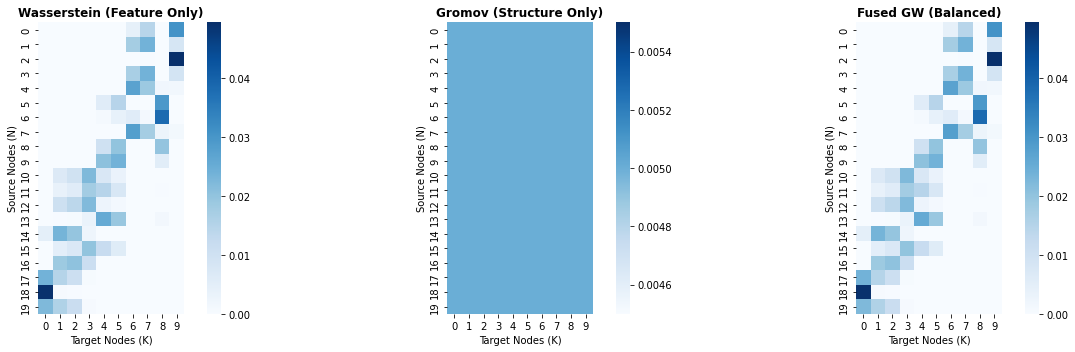

>>> Comparison: Alpha = 0.001


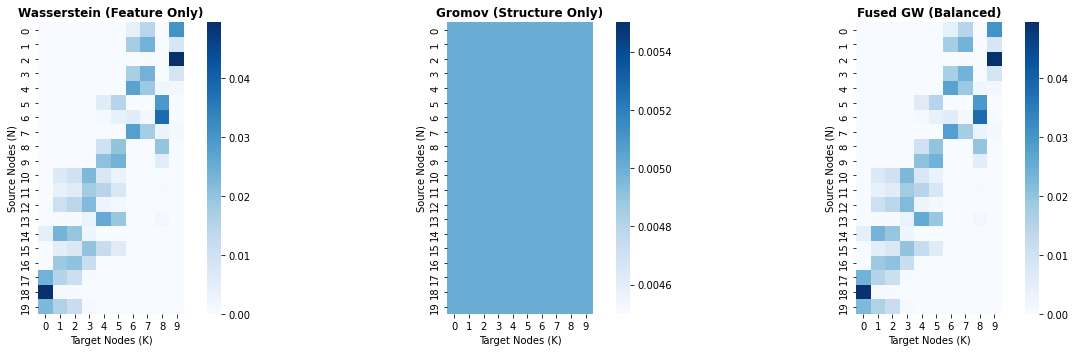

>>> Comparison: Alpha = 0.3


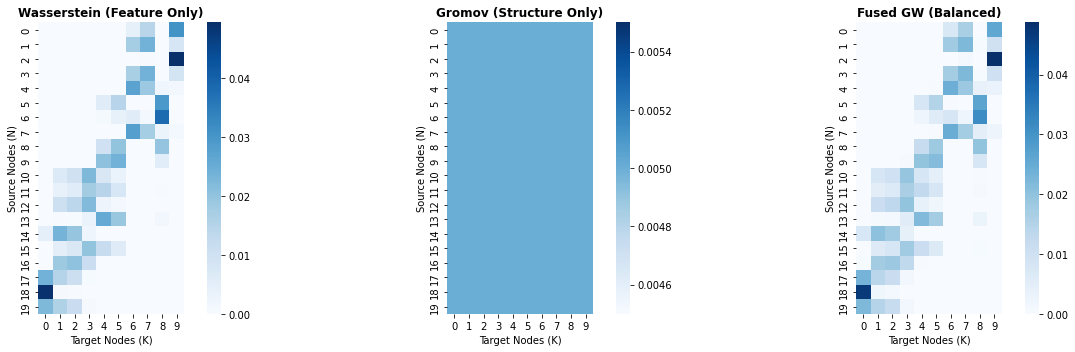

>>> Comparison: Alpha = 0.5


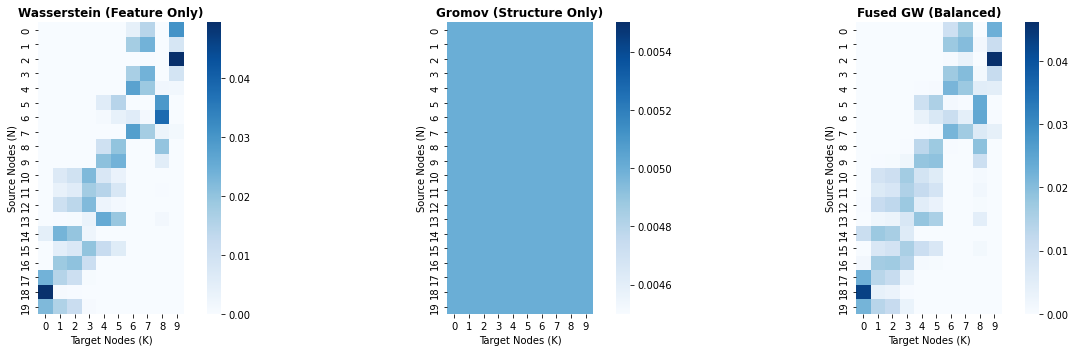

>>> Comparison: Alpha = 0.8


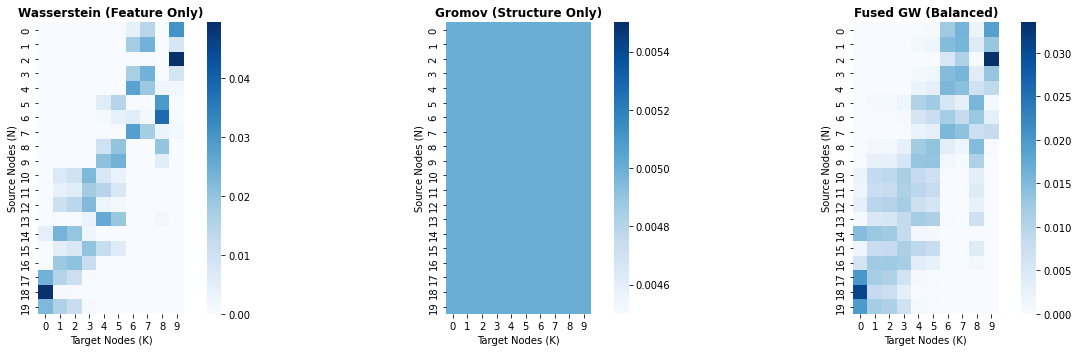

>>> Comparison: Alpha = 1.0


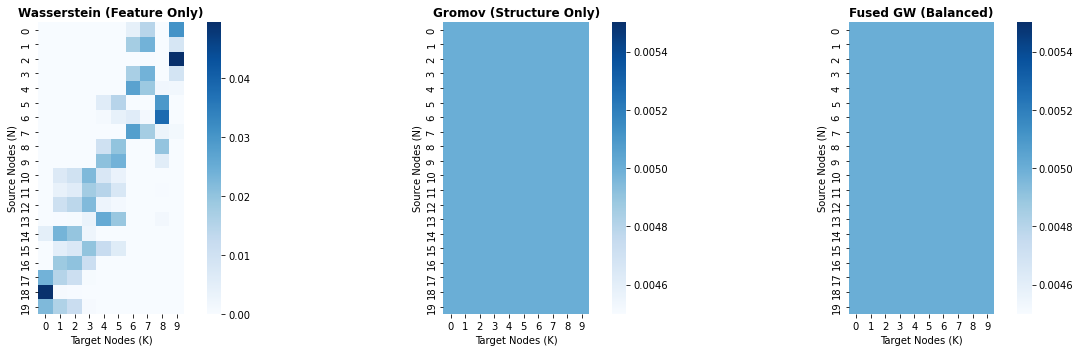


--- [2] Graph Matching (Connections) ---


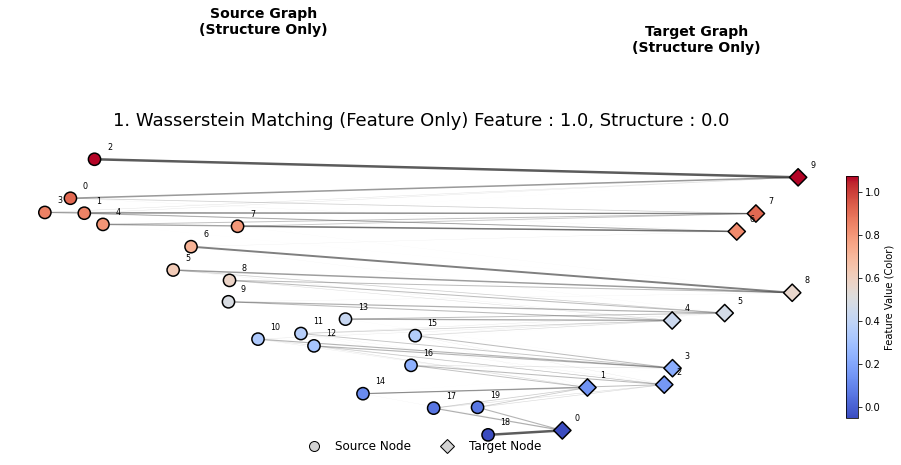

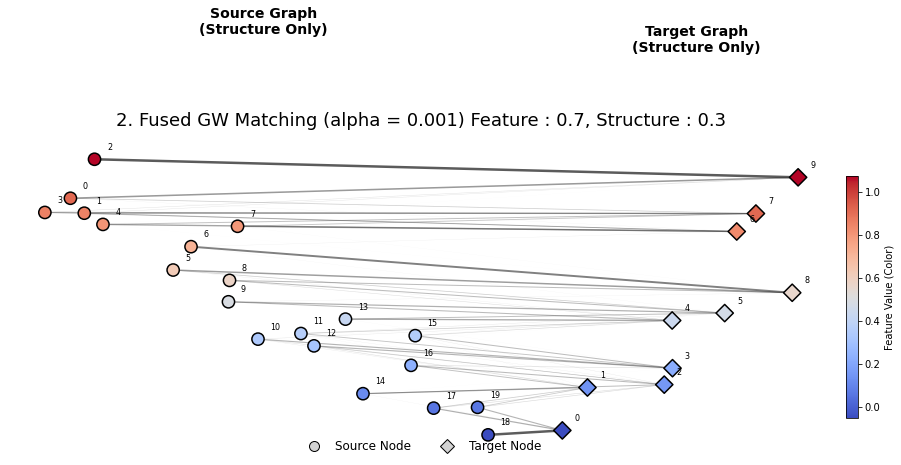

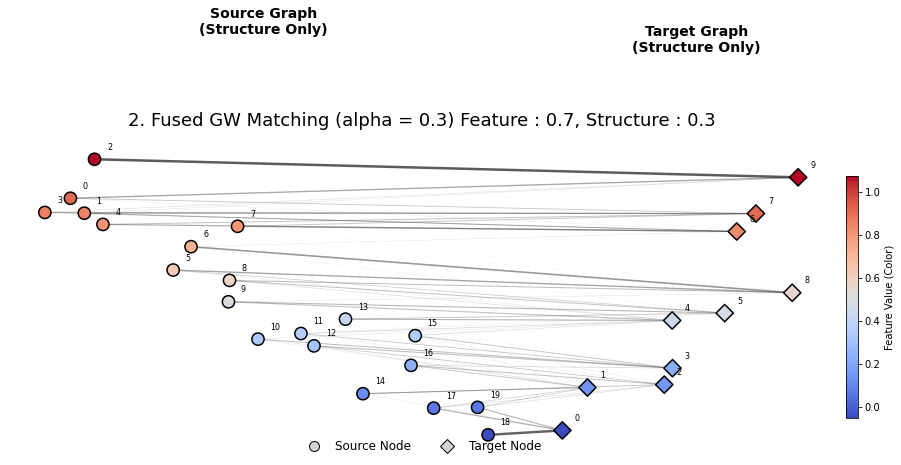

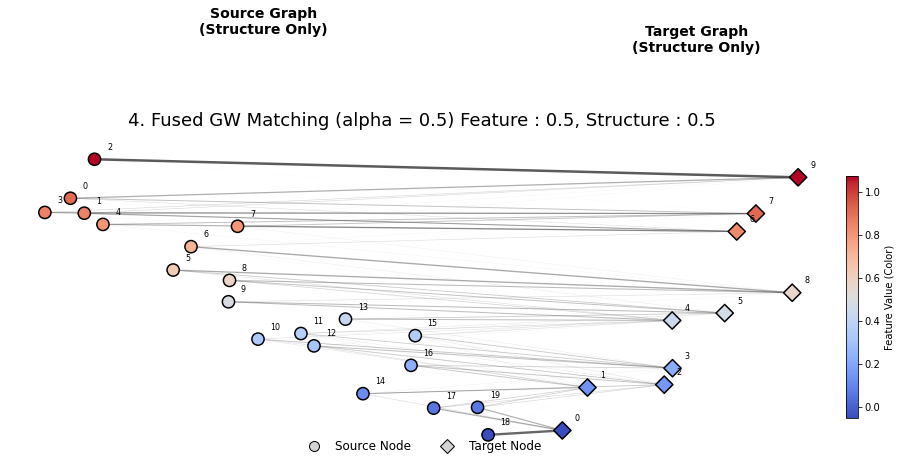

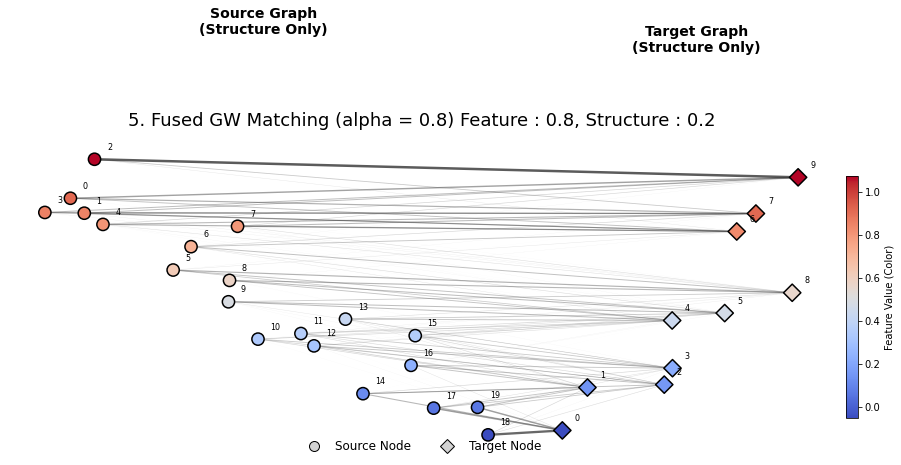

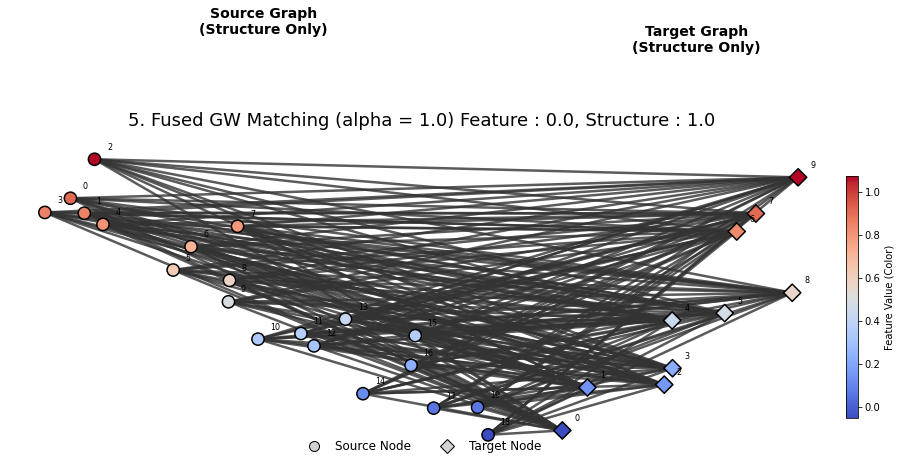

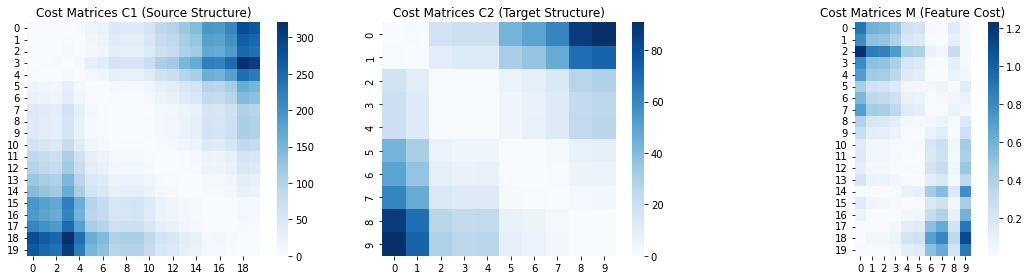


Comparing Wasserstein (alpha=0.0) vs Gromov (alpha=1.0):
  Sum of Absolute Differences (L1): 1.3715
  Max Absolute Difference (L-inf): 0.0445

Comparing Wasserstein (alpha=0.0) vs Fused GW (alpha=0.001):
  Sum of Absolute Differences (L1): 0.0003
  Max Absolute Difference (L-inf): 0.0000

Comparing Wasserstein (alpha=0.0) vs Fused GW (alpha=0.3):
  Sum of Absolute Differences (L1): 0.1264
  Max Absolute Difference (L-inf): 0.0071

Comparing Wasserstein (alpha=0.0) vs Fused GW (alpha=0.5):
  Sum of Absolute Differences (L1): 0.2482
  Max Absolute Difference (L-inf): 0.0140

Comparing Wasserstein (alpha=0.0) vs Fused GW (alpha=0.8):
  Sum of Absolute Differences (L1): 0.5813
  Max Absolute Difference (L-inf): 0.0256

Comparing Fused GW (alpha=0.3) vs Fused GW (alpha=0.5):
  Sum of Absolute Differences (L1): 0.1230
  Max Absolute Difference (L-inf): 0.0069


In [29]:
# --- 3. Run Solvers ---
epsilon_ = 0.01
# # 1. Wasserstein (alpha=0)
# print(">>> 1. Running Wasserstein Only (alpha=0)...")
Pi_W, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=0.0, epsilon=epsilon_)


Pi_GW, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=1.0, epsilon=epsilon_)
# 2. FGW Variatons
print(">>> 1. Running Wasserstein Only (alpha=0) Feature : 1.0, Structure : 0.0 ...")
Pi_FGW_00, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=0.0, epsilon=epsilon_)

print(">>> 2. Running Fused GW (alpha=0.3) Feature : 0.7, Structure : 0.3 ...")
Pi_FGW_0001, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=0.001, epsilon=epsilon_)

print(">>> 2. Running Fused GW (alpha=0.3) Feature : 0.7, Structure : 0.3 ...")
Pi_FGW_03, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=0.3, epsilon=epsilon_)

print(">>> 3. Running Fused GW (alpha=0.5) Feature : 0.5, Structure : 0.5 ...")
Pi_FGW_05, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=0.5, epsilon=epsilon_)

print(">>> 4. Running Fused GW (alpha=0.8) Feature : 0.8, Structure : 0.2 ...")
Pi_FGW_08, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=0.8, epsilon=epsilon_)

print(">>> 5. Running Gromov Only (alpha=1) Feature : 0.0, Structure : 1.0 ...")
Pi_FGW_10, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=1.0, epsilon=epsilon_)

# --- 4. Visualize ---

print("\n--- [1] Transport Plans (Heatmaps) ---")

print(">>> Comparison: Alpha = 0.0")
FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW_00)

print(">>> Comparison: Alpha = 0.001")
FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW_0001)

print(">>> Comparison: Alpha = 0.3")
FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW_03)

print(">>> Comparison: Alpha = 0.5")
FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW_05)

print(">>> Comparison: Alpha = 0.8")
FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW_08)

print(">>> Comparison: Alpha = 1.0")
FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW_10)

print("\n--- [2] Graph Matching (Connections) ---")

# (1) Wasserstein Matching
FGWVisualizer.plot_graph_matching(xs, ys, xt, yt, Pi_FGW_00, title="1. Wasserstein Matching (Feature Only) Feature : 1.0, Structure : 0.0")

# (2) FGW Matching (0.3)
FGWVisualizer.plot_graph_matching(xs, ys, xt, yt, Pi_FGW_0001, title="2. Fused GW Matching (alpha = 0.001) Feature : 0.7, Structure : 0.3")

# (2) FGW Matching (0.3)
FGWVisualizer.plot_graph_matching(xs, ys, xt, yt, Pi_FGW_03, title="2. Fused GW Matching (alpha = 0.3) Feature : 0.7, Structure : 0.3")

# (3) FGW Matching (0.5)
FGWVisualizer.plot_graph_matching(xs, ys, xt, yt, Pi_FGW_05, title="4. Fused GW Matching (alpha = 0.5) Feature : 0.5, Structure : 0.5")

# (4) FGW Matching (0.8)
FGWVisualizer.plot_graph_matching(xs, ys, xt, yt, Pi_FGW_08, title="5. Fused GW Matching (alpha = 0.8) Feature : 0.8, Structure : 0.2")

# (5) FGW Matching (0.8)
FGWVisualizer.plot_graph_matching(xs, ys, xt, yt, Pi_FGW_10, title="5. Fused GW Matching (alpha = 1.0) Feature : 0.0, Structure : 1.0")

# Cost Matrices
FGWVisualizer.plot_matrices(C1, C2, M, title_prefix="Cost Matrices")



# 1. Wasserstein vs Gromov (가장 큰 차이)
diff_W_vs_GW = compare_plans(Pi_W, Pi_GW, "Wasserstein (alpha=0.0)", "Gromov (alpha=1.0)")

# 2. Wasserstein vs Fused (alpha=0.3)
diff_W_vs_FGW03 = compare_plans(Pi_W, Pi_FGW_0001, "Wasserstein (alpha=0.0)", "Fused GW (alpha=0.001)")

# 3. Wasserstein vs Fused (alpha=0.3)
diff_W_vs_FGW03 = compare_plans(Pi_W, Pi_FGW_03, "Wasserstein (alpha=0.0)", "Fused GW (alpha=0.3)")

# 4. Wasserstein vs Fused (alpha=0.5)
diff_W_vs_FGW05 = compare_plans(Pi_W, Pi_FGW_05, "Wasserstein (alpha=0.0)", "Fused GW (alpha=0.5)")

# 5. Wasserstein vs Fused (alpha=0.8)
diff_W_vs_FGW08 = compare_plans(Pi_W, Pi_FGW_08, "Wasserstein (alpha=0.0)", "Fused GW (alpha=0.8)")

# 6. alpha 0.3 vs alpha 0.5
diff_03_vs_05 = compare_plans(Pi_FGW_03, Pi_FGW_05, "Fused GW (alpha=0.3)", "Fused GW (alpha=0.5)")

#### GRAPH ATTENTION

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset
import logging
import sys
import io
from pathlib import Path
import pickle 
from sklearn.model_selection import train_test_split 
import random 
import os 
import math 
from torch import Tensor 

# --- (필수) 프로젝트 경로 설정 ---
PROJECT_ROOT = "/home/eungyeop/LLM/tabular/ProtoLLM" # ❗️ (경로 확인)
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from utils.util import fix_seed
from dataset.data_dataloaders import prepare_embedding_dataloaders
# ❗️ [수정] Model 대신 BasisGATLayer 임포트
from models.BasisGraphAttention import BasisGATLayer_MUL, BasisGATLayer_IND 
from argparse import Namespace
# ----------------------------------------

# --- 로거 설정 ---
logger = logging.getLogger("step2_vq_logger")
# ... (이하 로거 설정 동일) ...

print("Imports and Logger initialized.")

Imports and Logger initialized.


In [59]:
class GAT_Encoder(nn.Module):
    """
    Model.predict()에서 GAT 스택 부분만 추출한 인코더.
    [CLS] 토큰, [나머지 노드 임베딩], 그리고 마지막 레이어의 Affinity(Attention)를 반환합니다.
    """
    def __init__(self, args):
        super().__init__()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.args = args
        self.input_dim = args.input_dim
        self.hidden_dim = args.hidden_dim
        self.num_basis_layers = args.num_basis_layers
        self.dropout_rate = args.dropout_rate
        
        # CLS 토큰
        self.basis_cls = nn.Parameter(torch.Tensor(1, 1, self.input_dim))
        nn.init.uniform_(self.basis_cls, a=-1/math.sqrt(self.input_dim), b=1/math.sqrt(self.input_dim))
        
        # GAT 레이어 (args.basis_type에 따라 분기)
        if args.basis_type == 'mul':
            self.basis_layers = nn.ModuleList([ 
                BasisGATLayer_MUL(args, input_dim = self.input_dim, hidden_dim = self.hidden_dim, num_basis_heads = args.num_basis_heads, dropout = self.dropout_rate)
                for _ in range(self.num_basis_layers)
            ])
        elif args.basis_type == 'ind':
            self.basis_layers = nn.ModuleList([ 
                BasisGATLayer_IND(args, input_dim = self.input_dim, hidden_dim = self.hidden_dim, num_basis_heads = args.num_basis_heads, dropout = self.dropout_rate)
                for _ in range(self.num_basis_layers)
            ])
        self.basis_layer_norms = nn.ModuleList([ 
            nn.LayerNorm(self.input_dim) for _ in range(self.num_basis_layers)
        ])
        
        self.x_basis = None # (디버깅용)

    def forward(self, batch):
        # ❗️ [수정] Model.predict()의 "gather" 로직을 그대로 복사
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'].to(self.device))
            name_embeddings.append(batch['cat_name_embeddings'].to(self.device))
            value_embeddings.append(batch['cat_value_embeddings'].to(self.device))
        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings', 'num_name_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'].to(self.device))
            name_embeddings.append(batch['num_name_embeddings'].to(self.device))
            value_embeddings.append(batch['num_prompt_embeddings'].to(self.device))
        
        if not desc_embeddings or not name_embeddings or not value_embeddings:
             raise ValueError("No categorical or numerical features found in batch (e.g., 'cat_name_embeddings' or 'num_prompt_embeddings')")

        desc = torch.cat(desc_embeddings, dim = 1)
        name = torch.cat(name_embeddings, dim = 1)
        value = torch.cat(value_embeddings, dim = 1)
        # --- [Gather 로직 끝] ---
        x_basis = torch.cat([self.basis_cls.expand(value.size(0), 1, self.input_dim), value], dim=1)
        last_att = None
        # --- [ ❗️ Post-Norm으로 수정된 루프 ❗️ ] ---
        for l in range(self.num_basis_layers):
            # 1. Layer (Norm을 먼저 적용하지 않음)
            basis_outputs, att = self.basis_layers[l](name, x_basis) 
            
            # 2. Residual Add
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), self.input_dim)
            
            # 3. Norm (마지막에 적용)
            x_basis = self.basis_layer_norms[l](x_basis) 
            
            last_att = att
        
        self.x_basis = x_basis
        
        # [CLS] 토큰 추출 (0번째 인덱스)
        z_e_cls = x_basis[:, 0, :] # [B, D_full]

        # ❗️ [추가] 나머지 노드 임베딩 추출 (1번째 인덱스부터 끝까지)
        z_e_nodes = x_basis[:, 1:, :] # [B, N-1, D_full]
        
        # ❗️ [수정] CLS, Nodes, Affinity 3가지를 반환
        return z_e_cls, z_e_nodes, last_att

# -----------------------------------------------------------------
# 시각화 함수는 기존 로직 유지 (변경 없음)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
def visualize_affinity(affinity_tensor, batch_idx=0):
    if affinity_tensor is None:
        print("Affinity 텐서가 None입니다. 시각화를 스킵합니다.")
        return
    
    try:
        affinity_np = affinity_tensor.detach().cpu().numpy()
    except Exception as e:
        print(f"텐서 변환 중 오류 발생: {e}")
        return

    if batch_idx >= affinity_np.shape[0]:
        print(f"배치 인덱스 {batch_idx}가 배치 크기({affinity_np.shape[0]})보다 큽니다. 0번 인덱스를 사용합니다.")
        batch_idx = 0
    att_sample = affinity_np[batch_idx] 
    
    num_heads = att_sample.shape[0]
    num_nodes = att_sample.shape[1]

    nrows, ncols = 2, 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(22, 18))
    
    labels = ['[CLS]'] + [f'Node {i}' for i in range(1, num_nodes)]

    for i in range(num_heads):
        if i >= 4: break # 예외 처리
        ax = axes.flatten()[i]
        head_data = att_sample[i]
        
        sns.heatmap(
            head_data, 
            xticklabels=labels, 
            yticklabels=labels, 
            cmap='viridis',
            square=True,
            cbar=True,
            cbar_kws={"shrink": .75},
            linewidths=.5,
            linecolor='black',
            annot=True,
            fmt='.3f',
            annot_kws={"size": 10},
            ax=ax
        )
        ax.set_title(f"Affinity - Head {i}", fontsize=12)
        ax.set_xlabel("Key (Attended To)", fontsize=10)
        ax.set_ylabel("Query (Attending From)", fontsize=10)
        
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        plt.setp(ax.get_yticklabels(), rotation=0)

    fig.suptitle(f"Per-Head Attention Affinity (Batch Item {batch_idx})", fontsize=20, y=1.03)
    plt.tight_layout()
    plt.show()

print("GAT_Encoder (returning CLS, Nodes, Affinity) defined.")

GAT_Encoder (returning CLS, Nodes, Affinity) defined.


In [60]:
#
# ❗️ (블럭 3) 덮어쓰기
#
# --- 1. 하이퍼파라미터 ---
D_FULL = 768    # GAT의 input_dim (get_args() 기본값 768)
N_BASIS_HEADS = 1 # H
K_CODES = 64     # LCG M=8 -> K=8
BETA = 0.5     # VQ Commitment 가중치
LEARNING_RATE = 1e-3
N_EPOCHS = 200 
BATCH_SIZE = 32
DATASET_NAME = "heart_target_1" 

# --- 2. 훈련용 "가짜" args 생성 (get_args() 기반) ---
args = Namespace() 

# (GAT_Encoder __init__용)
args.input_dim = D_FULL
args.hidden_dim = 192 # (get_args() 기본값)
args.num_basis_layers = 2 # (get_args() 기본값)
args.dropout_rate = 0.1
args.num_basis_heads = N_BASIS_HEADS
args.basis_type = 'ind' # ❗️ (IND 레이어 사용)

# (BasisGATLayer_IND __init__용)
args.attn_type = 'gat_v1' 
args.no_self_loop = False
args.edge_type = 'normal' 

# (prepare_embedding_dataloaders용)
args.random_seed = 42
args.batch_size = BATCH_SIZE 
args.llm_model = "gpt2_mean" 
args.embed_type = "carte"
args.source_data = [DATASET_NAME] # (GAT_Encoder는 사용하지 않지만 로더가 필요)
# ----------------------------------------------------

# --- 3. 실제 데이터 로드 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device: {device}")

res = prepare_embedding_dataloaders(args, DATASET_NAME)

train_loader, val_loader, test_loader = res['loaders']
args.num_classes = res['num_classes']
args.output_dim = 1 # (이진 분류 확인)

# (데이터 로더가 input_dim을 덮어쓰므로, GAT용으로 재설정)
args.input_dim = D_FULL 

# ❗️ [수정] PCA용 데이터 추출 루프 (KeyError 원인) 삭제.
# (시각화는 (블럭 5)에서 test_loader로 수행)

logger.info(f"Data for '{DATASET_NAME}' loaded.")
logger.info(f"GAT Input Dim (D_full): {args.input_dim}")
logger.info(f"Num Classes: {args.num_classes}")

Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_1.pkl
Training data size: 173
Validation data size: 58
Test data size: 58


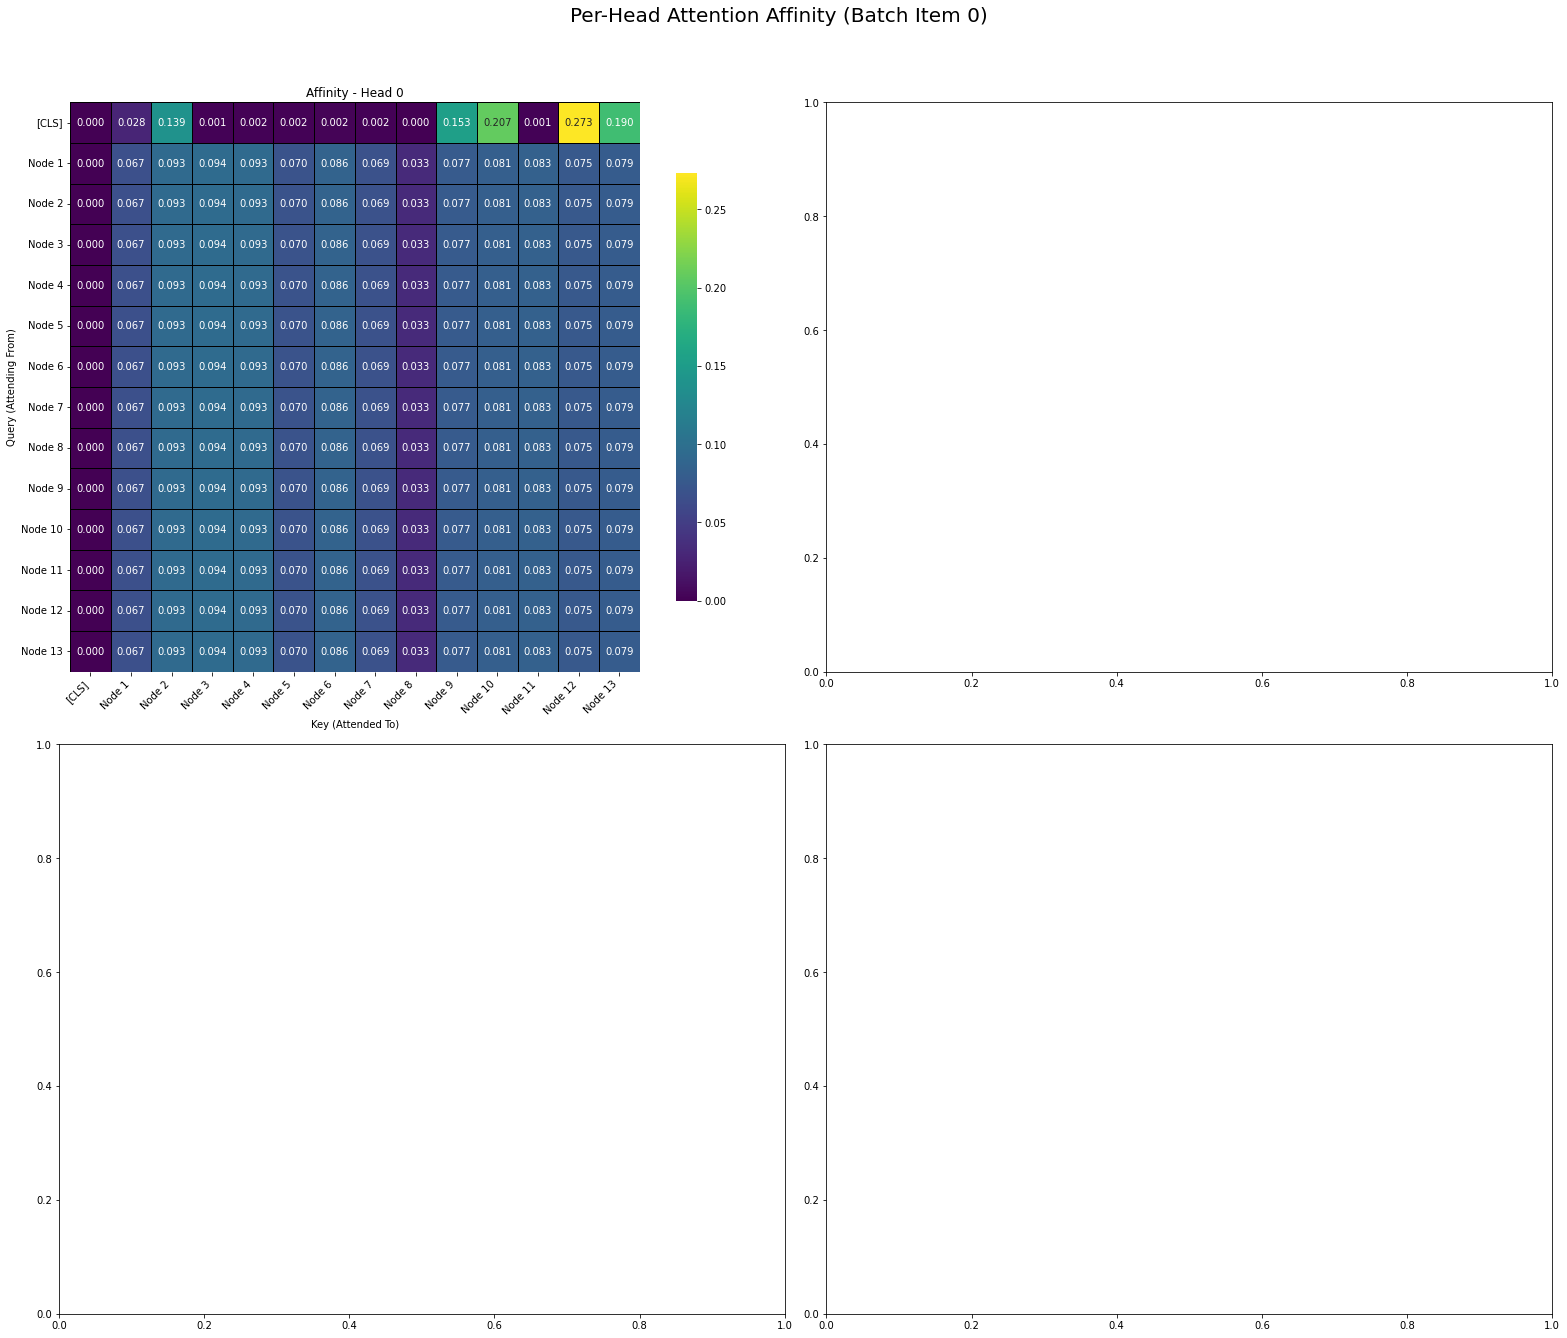

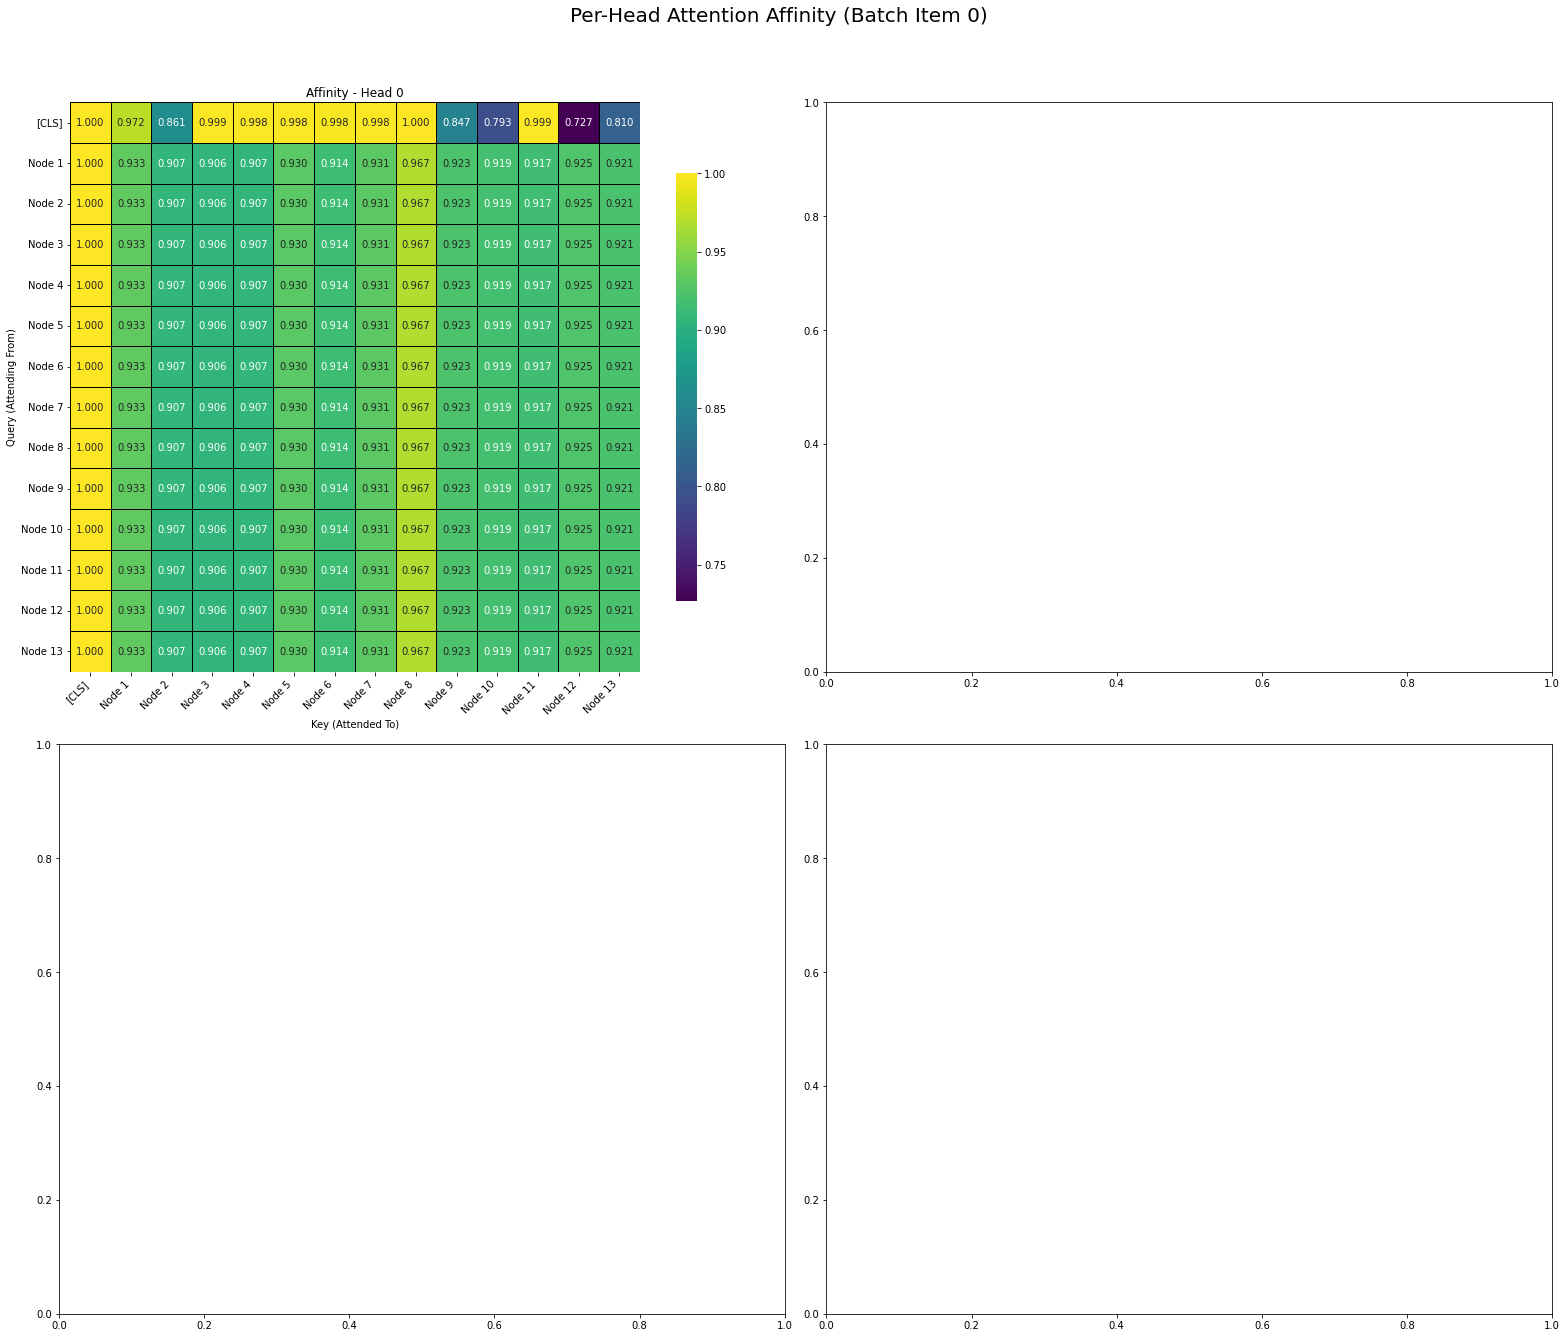

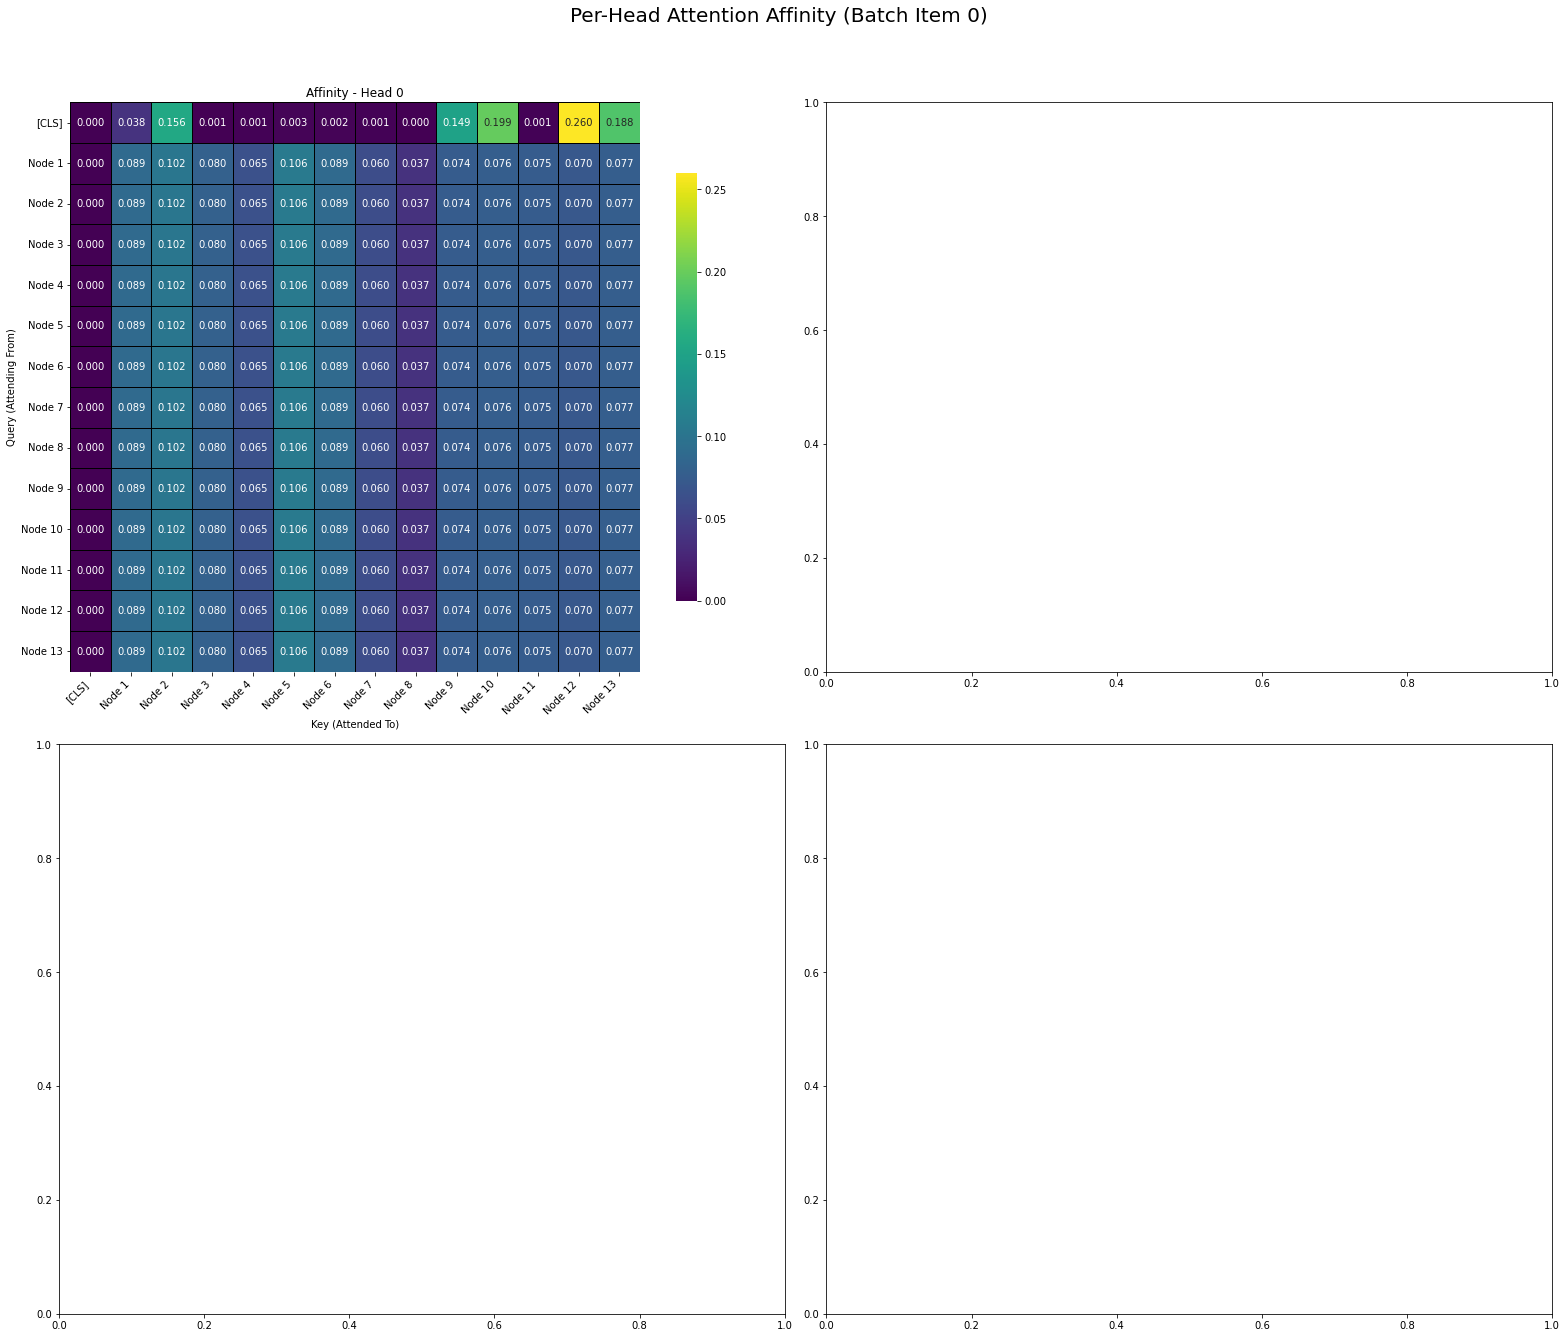

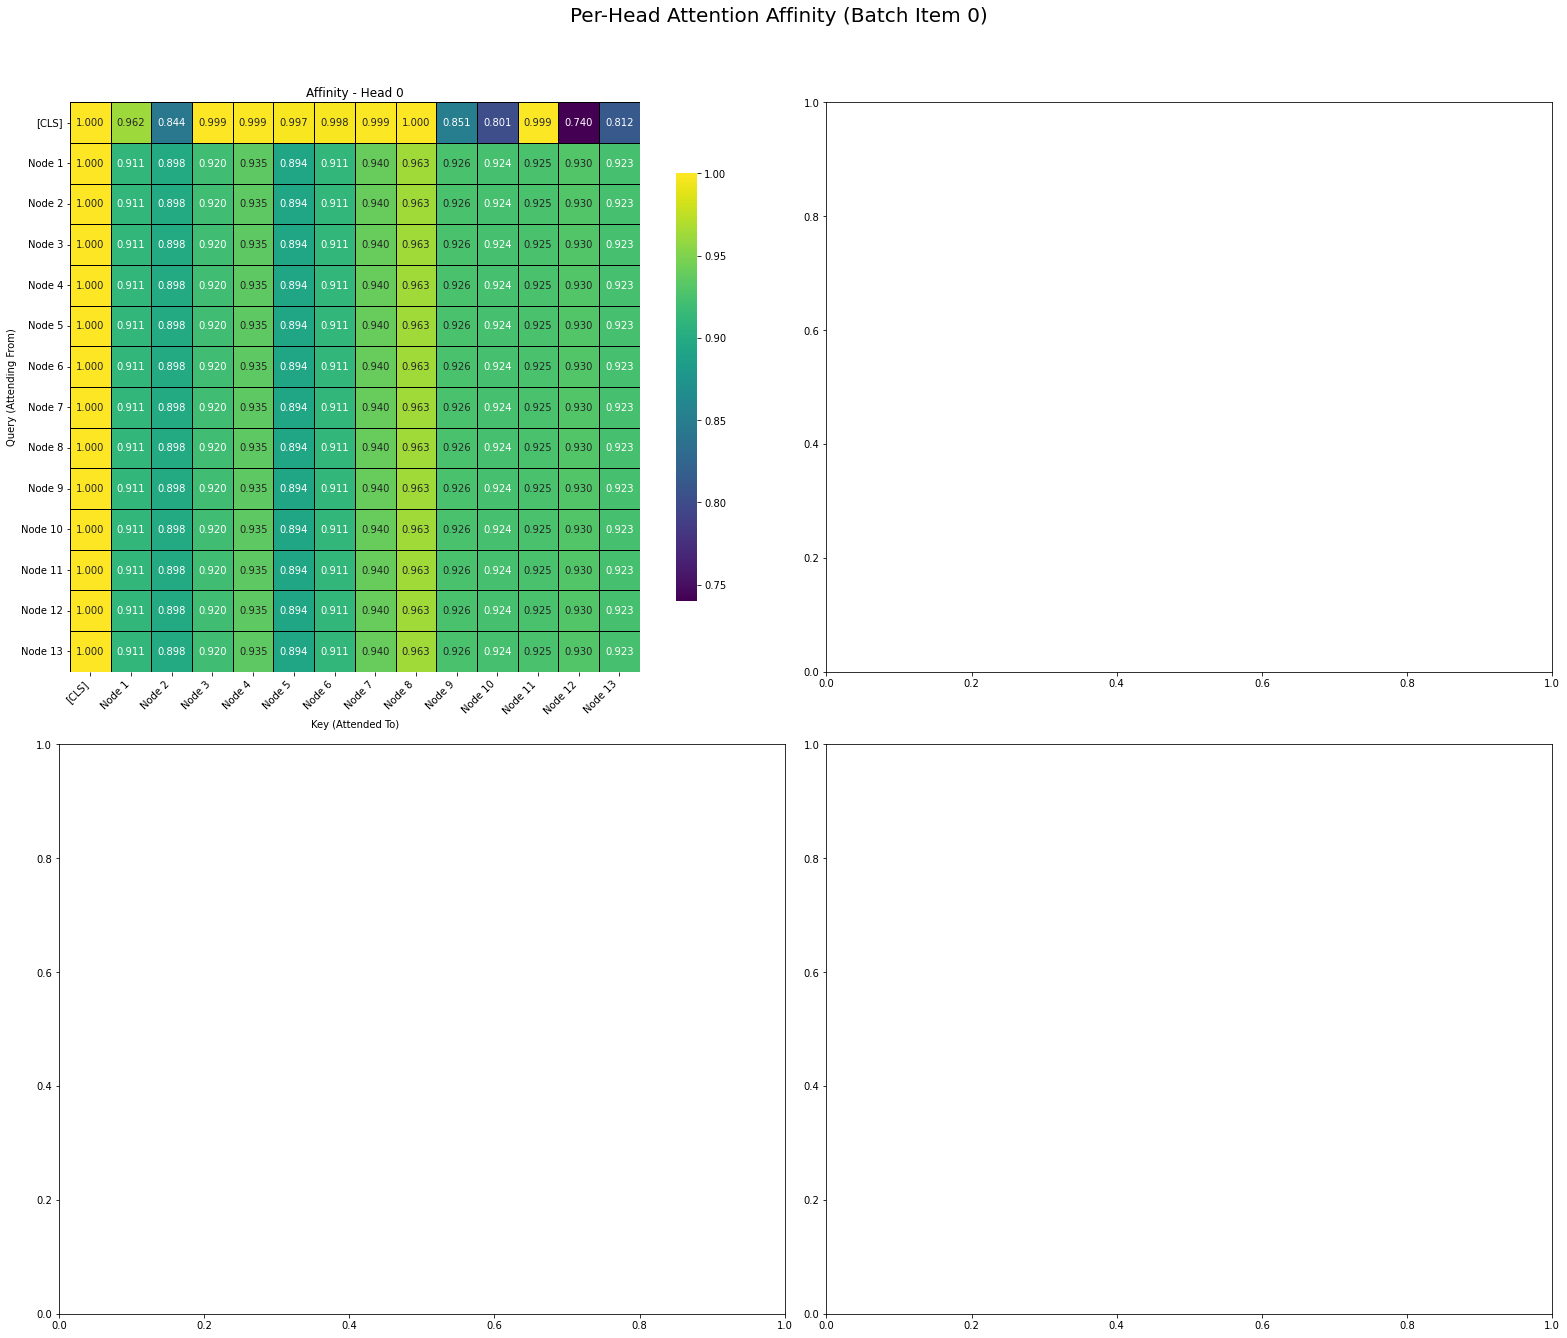

In [61]:

class SimplePredictor(nn.Module):
    def __init__(self, input_dim, output_dim, hid=256, dropout_rate=0.1):
        super().__init__()
        self.ghead = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, hid),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hid, output_dim)
        )
    def forward(self, x):
        return self.ghead(x)

# --- 1. GAT 인코더 초기화 ---
gat_encoder = GAT_Encoder(args).to(device) 

# --- 2. SimplePredictor 초기화 ---
predictor = SimplePredictor(
    input_dim=args.input_dim,
    output_dim=args.output_dim,
    hid=256, 
    dropout_rate=args.dropout_rate
).to(device)

# --- 3. 옵티마이저 ---
optimizer = optim.Adam(
    list(gat_encoder.parameters()) + list(predictor.parameters()), 
    lr=LEARNING_RATE
)

# --- 4. Loss 함수 정의 ---
criterion = nn.BCEWithLogitsLoss()

logger.info("GAT Encoder and SimplePredictor initialized FROM SCRATCH.")

# --- 5. 모니터링용 ---
history = {
    'epoch': [], 
    'train_auc': [], 'val_auc': [],
    'z_e_l2': []
}
current_step = 0

# --- 6. 학습/검증 루프 ---
for epoch in range(N_EPOCHS):
    
    # --- 훈련 ---
    gat_encoder.train()
    predictor.train() 
    
    train_losses, train_preds, train_labels = [], [], []
    
    for batch in train_loader:
        batch_y = batch['y'].to(device) 
        # ❗️ [수정] 반환값 3개 (Nodes는 학습 루프에선 사용 안 함)
        z_e_cls, _, last_affinity = gat_encoder(batch) 
        
        logits = predictor(z_e_cls)
        loss = criterion(logits, batch_y.float()) 
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        train_preds.append(torch.sigmoid(logits).detach().cpu()) 
        train_labels.append(batch['y'].cpu()) 
        
        current_step += 1
        
        if current_step % 10 == 0:
            with torch.no_grad():
                z_e_l2_sq = (z_e_cls**2).sum(-1).mean().item()
            logger.info("--- 📊 GAT Output (Instantaneous) ---")
            logger.info(f"  [z_e (CLS)] L2_norm_sq: {z_e_l2_sq:.4f}")
            logger.info(f"[Step {current_step}] Current Task Loss: {loss.item():.4f}")

    # --- 검증 ---
    gat_encoder.eval()
    predictor.eval() 
    
    val_preds, val_labels = [], []
    all_val_z_e = []
    
    with torch.no_grad():
        for batch in val_loader:
            batch_y = batch['y'].to(device)
            # ❗️ [수정] 반환값 3개 언패킹
            z_e_cls, _, _ = gat_encoder(batch)
            
            logits = predictor(z_e_cls)
            val_preds.append(torch.sigmoid(logits).cpu()) 
            val_labels.append(batch['y'].cpu())
            all_val_z_e.append(z_e_cls.cpu())

    # --- 에포크 말 로깅 ---
    train_auc = roc_auc_score(torch.cat(train_labels).numpy(), torch.cat(train_preds).numpy())
    val_auc = roc_auc_score(torch.cat(val_labels).numpy(), torch.cat(val_preds).numpy())
    val_z_e_all = torch.cat(all_val_z_e, dim=0)
    val_z_e_l2_sq = (val_z_e_all**2).sum(-1).mean().item()
    
    history['epoch'].append(epoch)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)
    history['z_e_l2'].append(val_z_e_l2_sq)
    
    logger.info(
        f"[Epoch {epoch:3d}/{N_EPOCHS}] | "
        f"Train AUC: {train_auc:.4f} | "
        f"Val AUC: {val_auc:.4f}"
    )

logger.info("--- GAT + SimplePredictor 훈련 완료 ---")


#
# ❗️ [수정] 훈련 완료 후, 모든 정보(CLS, Nodes, Affinity) 저장
#
logger.info("--- 📈 Visualizing & Saving Final Embeddings (from val_loader) ---")
gat_encoder.eval()

# ❗️ [추가] 저장을 위한 리스트 초기화
final_cls_list = []
final_nodes_list = [] # ❗️ Node Embeddings 저장용
final_affinity_list = []

with torch.no_grad():
    try:
        # ❗️ val_loader 전체를 순회
        for i, batch in enumerate(val_loader):
            # ❗️ [수정] 3가지 반환값 모두 받기
            z_e_cls, z_e_nodes, affinity = gat_encoder(batch) 
            
            # ❗️ [추가] CPU로 이동하여 리스트에 저장
            final_cls_list.append(z_e_cls.cpu())
            final_nodes_list.append(z_e_nodes.cpu())
            final_affinity_list.append(affinity.cpu())

            # ❗️ 첫 번째 배치만 시각화 (기존 로직 유지)
            if i //5 == 0:
                logger.info(f"Visualizing affinity for first batch (shape: {affinity.shape})")
                visualize_affinity(affinity, batch_idx=0)
                visualize_affinity(1-affinity, batch_idx=0)
        
        # ❗️ [추가] 텐서들을 하나로 결합
        all_cls_tensors = torch.cat(final_cls_list, dim=0)
        all_nodes_tensors = torch.cat(final_nodes_list, dim=0) # [Total_Samples, N-1, D]
        all_affinity_tensors = torch.cat(final_affinity_list, dim=0)

        # ❗️ [추가] 딕셔너리에 z_e_nodes 추가
        affinity_results_dict = {
            'z_e_cls': all_cls_tensors,     # Shape: [Total_Samples, D_full]
            'z_e_nodes': all_nodes_tensors, # Shape: [Total_Samples, Num_Nodes, D_full] 
            'affinity': all_affinity_tensors # Shape: [Total_Samples, H, N, N]
        }
        
        logger.info(f"--- 💾 All results saved to dictionary ---")
        logger.info(f"affinity_results_dict['z_e_cls'].shape: {all_cls_tensors.shape}")
        logger.info(f"affinity_results_dict['z_e_nodes'].shape: {all_nodes_tensors.shape}")
        logger.info(f"affinity_results_dict['affinity'].shape: {all_affinity_tensors.shape}")
        
        # (저장 예시)
        # torch.save(affinity_results_dict, "final_gat_embeddings.pt")

    except Exception as e:
        logger.error(f"결과 저장 중 오류 발생: {e}")
        import traceback
        traceback.print_exc()

In [19]:
affinity_results_dict.keys()

dict_keys(['z_e_cls', 'z_e_nodes', 'affinity'])

In [38]:
print(affinity_results_dict['z_e_cls'][0].shape)
print(affinity_results_dict['affinity'][0].shape)
print(affinity_results_dict['z_e_nodes'][0].shape)

torch.Size([768])
torch.Size([1, 14, 14])
torch.Size([13, 768])


In [ ]:
affinity_results_dict['z_e_cls'].mean

Sample 0 내부의 12개 노드 간 임베딩 분산(std): 1.0153727531433105


In [ ]:
# --- 0. 시각화 헬퍼 함수 ---
def plot_single_plan(Pi_tensor, title, ax):
    pi_np = Pi_tensor.squeeze().detach().cpu().numpy()
    sns.heatmap(pi_np, ax=ax, cmap='Blues', square=True, cbar=True)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Latent Nodes (K)")
    ax.set_ylabel("Source Nodes (N)")

print("--- 🔬 Latent Graph 훈련 시작 (FGWSolver, CLS 제외) ---")
# --- 0. 시각화 헬퍼 함수 ---
def plot_single_plan(Pi_tensor, title, ax):
    pi_np = Pi_tensor.squeeze().detach().cpu().numpy()
    sns.heatmap(pi_np, ax=ax, cmap='Blues', square=True, cbar=True)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Latent Nodes (K)")
    ax.set_ylabel("Source Nodes (N)")

print("--- 🔬 Latent Graph 훈련 시작 (GWE L2/dim + exp 정규화) ---")

# --- 1. 하이퍼파라미터 ---
K_nodes = 8
N_SAMPLES = affinity_results_dict['z_e_nodes'].shape[0] # 58
D_full = affinity_results_dict['z_e_nodes'].shape[2]    # 768
N_STEPS = 200
LEARNING_RATE = 1e-2
ALPHA_FGW = 0.5
EPSILON_FGW = 0.5
device = 'cuda' if torch.cuda.is_available() else 'cpu'


latent_features1 = nn.Parameter(torch.randn(K_nodes, D_full).to(device))
latent_features2 = nn.Parameter(torch.randn(K_nodes, D_full).to(device))
a_b = (torch.ones(1, K_nodes) / K_nodes).to(device)
b_b = (torch.ones(1, K_nodes) / K_nodes).to(device)




In [68]:

# # --- 6. 훈련 후 Plan 시각화 ---
# # --- 6. 훈련 후 Plan 시각화 ---
# print("\n--- 📊 훈련 후 (Final) Plan 계산 ---")
# with torch.no_grad():
#     C2_b_dist_sq = torch.cdist(latent_features, latent_features, p=2)**2
#     C2_b = (1.0 - torch.exp(-C2_b_dist_sq / D_full)).unsqueeze(0)   # (1, K, K)
    
#     M_b_dist_sq = torch.cdist(F1_b, latent_features, p=2)**2
#     M_b = 1.0 - torch.exp(-M_b_dist_sq / D_full)                    # (B, N, K)

# print("\n=== 🔍 GitHub FGW 시각화 (내 학습 결과 기반) ===")

# # B개 중 첫번째 sample만 사용
# F1 = F1_b[0]            # (N, D)
# C1 = C1_b[0]            # (N, N)
# C2 = C2_b[0]            # (K, K)
# M  = M_b[0]             # (N, K)

# a = a_b[0]              # (N)
# b = b_b[0]              # (K)

# # === 1. alpha=0: Wasserstein (feature only) ===
# Pi_W, _ = FGWSolver.fgw(
#     M=M.unsqueeze(0),
#     C1=C1.unsqueeze(0),
#     C2=C2.unsqueeze(0),
#     a=a.unsqueeze(0),
#     b=b.unsqueeze(0),
#     alpha=0.0,
#     epsilon=EPSILON_FGW
# )

# # === 2. alpha=1: Gromov (structure only) ===
# Pi_GW, _ = FGWSolver.fgw(
#     M=M.unsqueeze(0),
#     C1=C1.unsqueeze(0),
#     C2=C2.unsqueeze(0),
#     a=a.unsqueeze(0),
#     b=b.unsqueeze(0),
#     alpha=1.0,
#     epsilon=EPSILON_FGW
# )

# # === 3. alpha=0.5: Fused GW ===
# Pi_FGW, _ = FGWSolver.fgw(
#     M=M.unsqueeze(0),
#     C1=C1.unsqueeze(0),
#     C2=C2.unsqueeze(0),
#     a=a.unsqueeze(0),
#     b=b.unsqueeze(0),
#     alpha=0.5,
#     epsilon=EPSILON_FGW
# )

# # === 4. GitHub 시각화 그대로 적용 ===
# FGWVisualizer.plot_matrices(C1, C2, M, title_prefix="Trained Graph Example")
# FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW)

# # Target coordinate는 PCA로 다시 생성
# latent_pca = PCA(n_components=2).fit_transform(latent_features.detach().cpu().numpy())
# xt = latent_pca[:, 0]
# yt = latent_pca[:, 1]

# # Source nodes는 그냥 1D로 펼침 (너가 쓰던 방식 유지)
# N_nodes = F1.shape[0]
# xs = torch.zeros(N_nodes)
# ys = torch.linspace(N_nodes-1, 0, N_nodes)


🔬 Simple FGW Visualization: Two Random Latent Features
  - Nodes: 10
  - Dimension: 768
  - Device: cuda

📊 Computing costs...
  ✅ C1 shape: torch.Size([1, 10, 10])
  ✅ C2 shape: torch.Size([1, 10, 10])
  ✅ M shape: torch.Size([1, 10, 10])

🚀 Running FGW solvers...
>>> 1. Running Wasserstein Only (alpha=0) Feature : 1.0, Structure : 0.0 ...
>>> 2. Running Fused GW (alpha=0.001) Feature : 0.999, Structure : 0.001 ...
>>> 3. Running Fused GW (alpha=0.3) Feature : 0.7, Structure : 0.3 ...
>>> 4. Running Fused GW (alpha=0.5) Feature : 0.5, Structure : 0.5 ...
>>> 5. Running Fused GW (alpha=0.8) Feature : 0.2, Structure : 0.8 ...
>>> 6. Running Gromov Only (alpha=1) Feature : 0.0, Structure : 1.0 ...

--- [1] Transport Plans (Heatmaps) ---
>>> Comparison: Alpha = 0.0


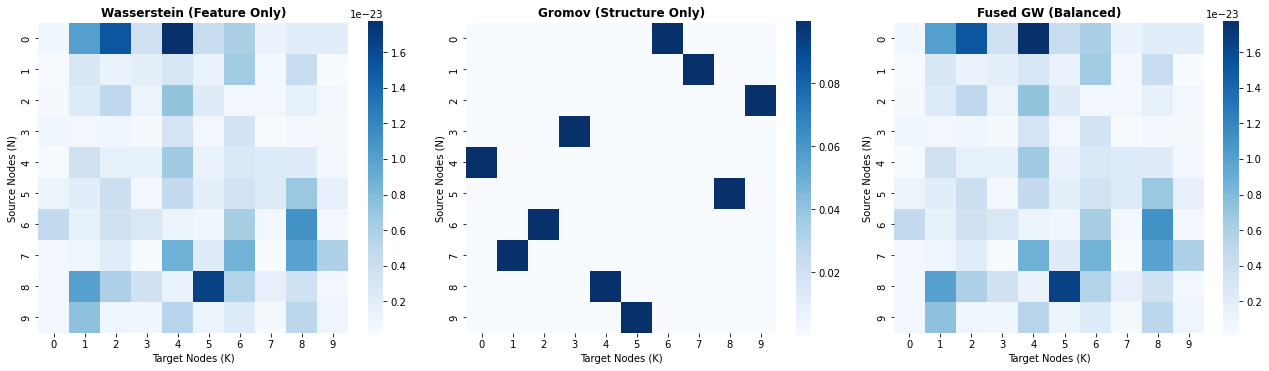

>>> Comparison: Alpha = 0.001


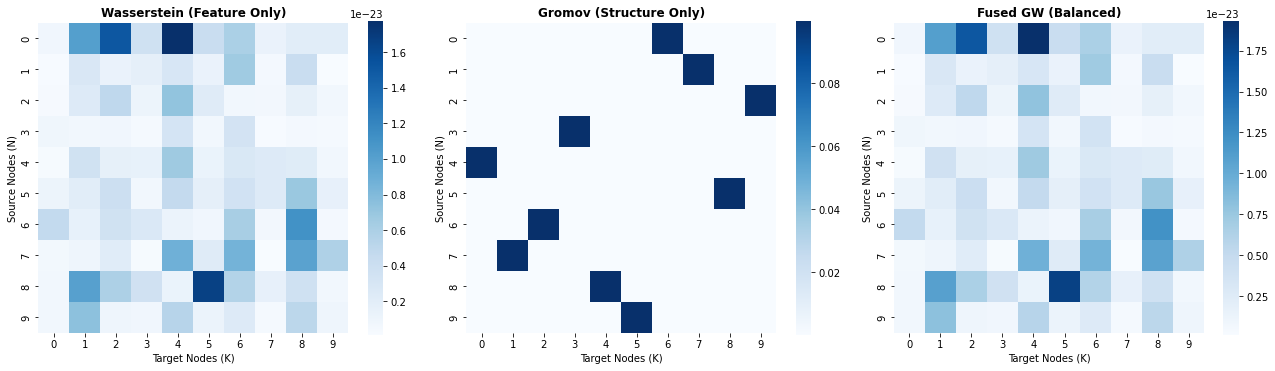

>>> Comparison: Alpha = 0.3


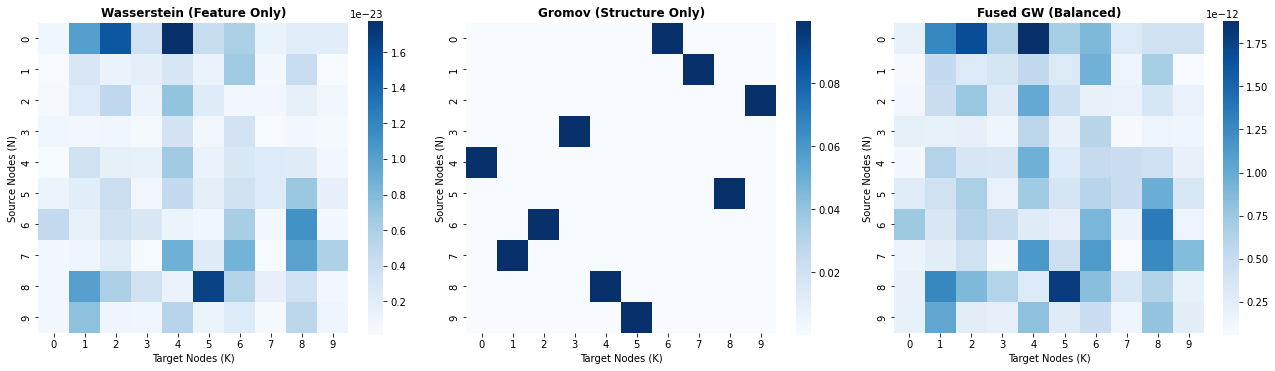

>>> Comparison: Alpha = 0.5


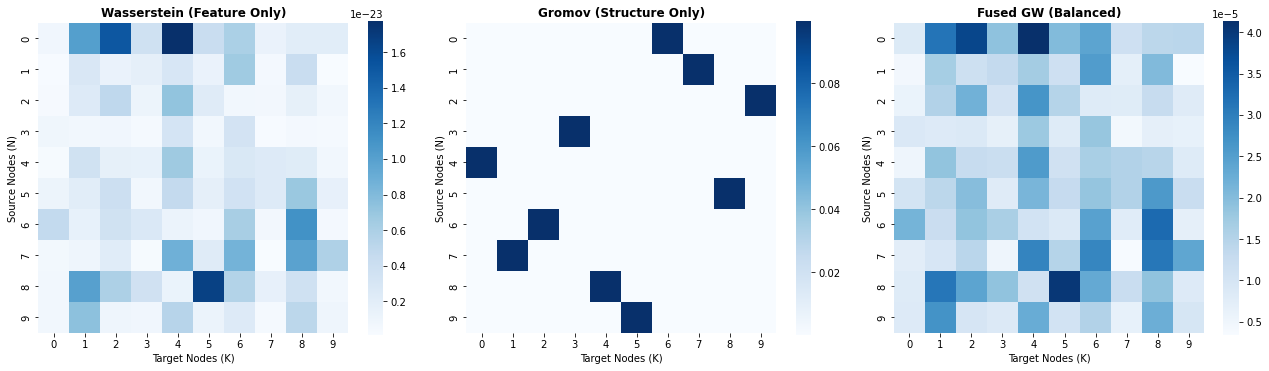

>>> Comparison: Alpha = 0.8


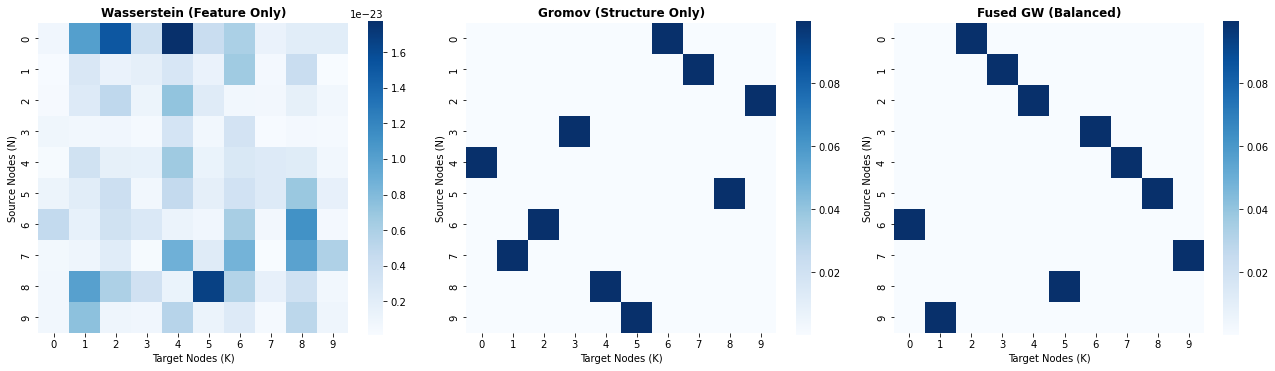

>>> Comparison: Alpha = 1.0


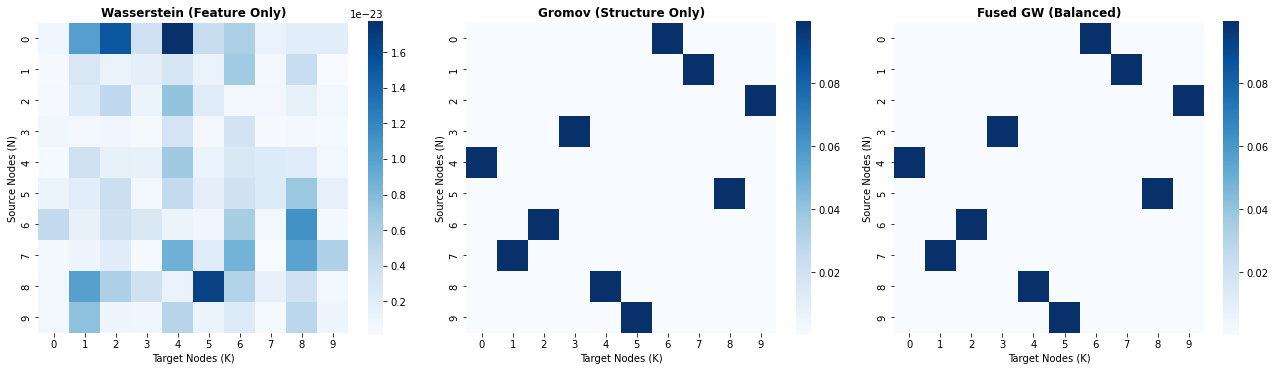


--- [2] Graph Matching (Connections) ---


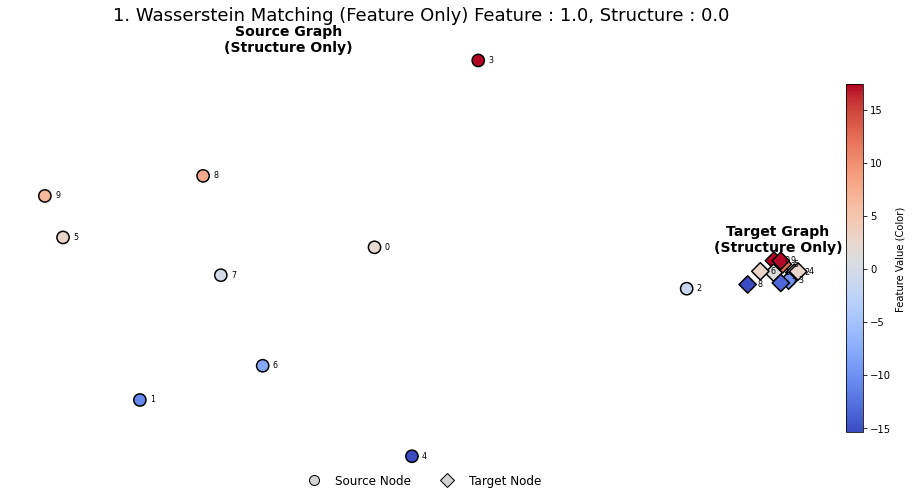

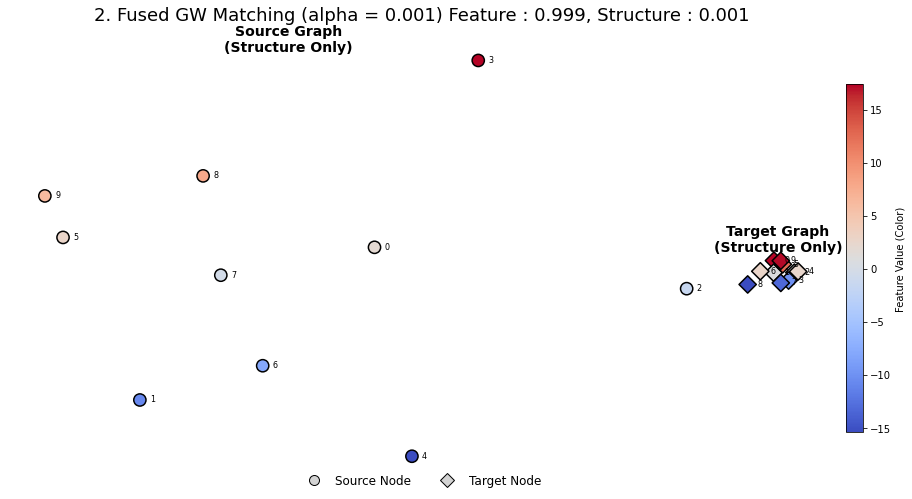

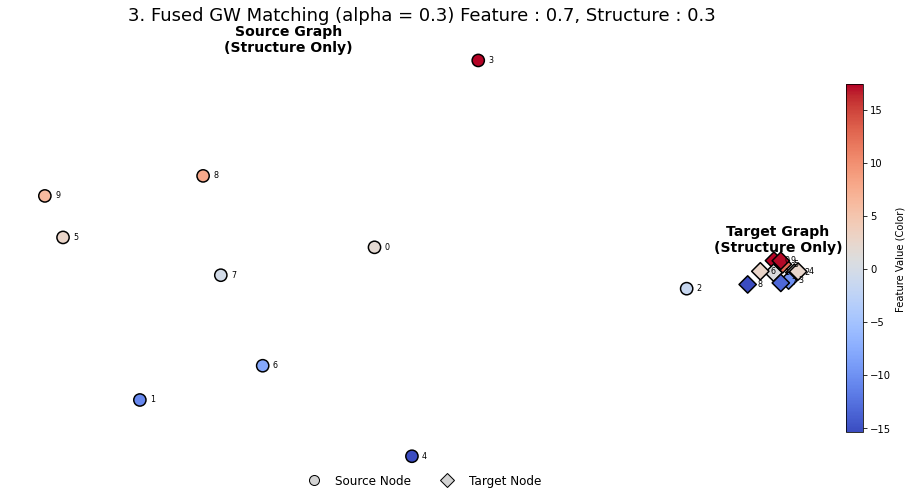

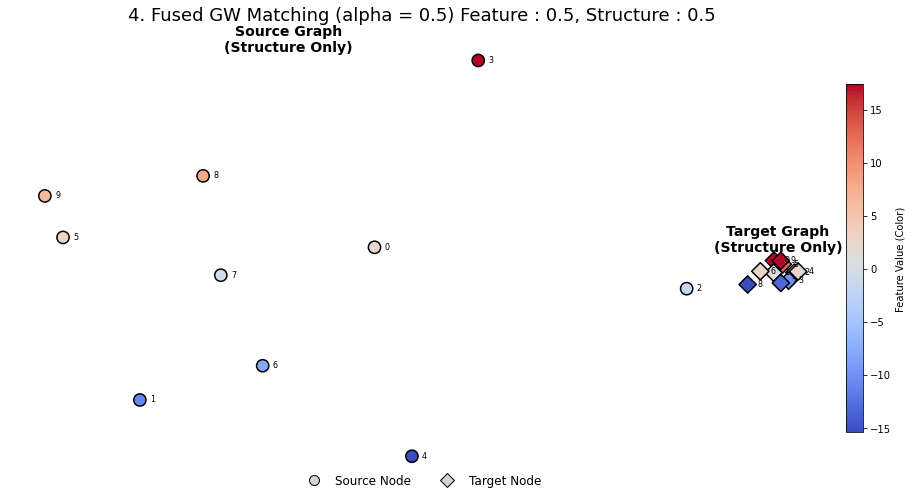

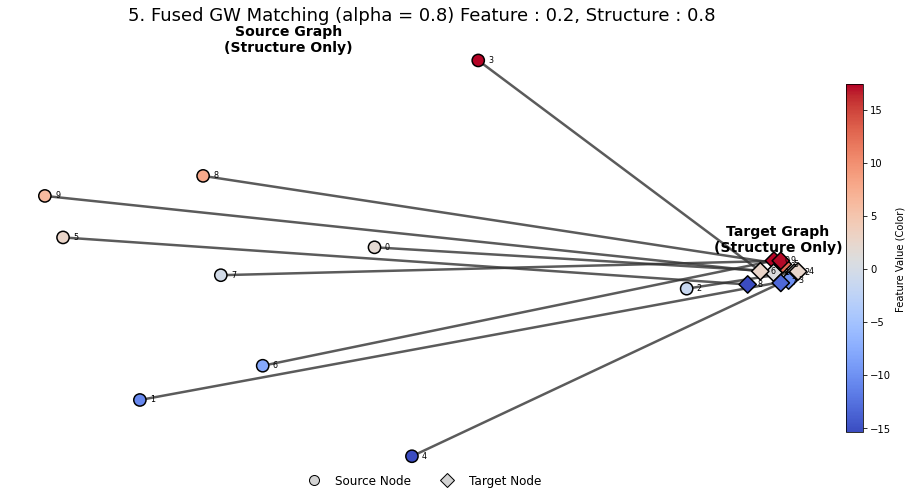

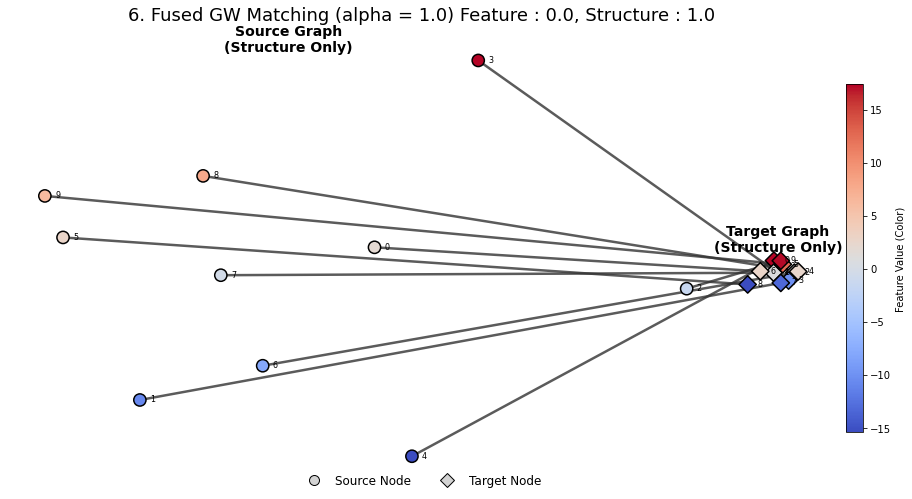


--- [3] Cost Matrices ---


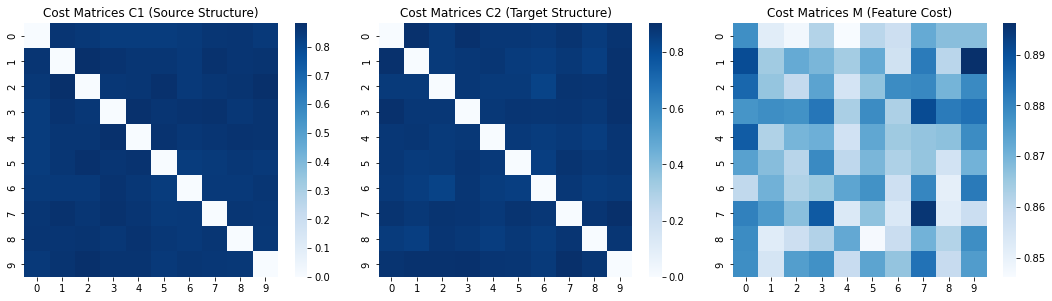


--- [4] Plan Comparisons ---

  Wasserstein (alpha=0.0) vs Gromov (alpha=1.0):
    Max difference: 0.100000
    Mean difference: 0.010000
    L2 norm of diff: 0.316227

  Wasserstein (alpha=0.0) vs Fused GW (alpha=0.001):
    Max difference: 0.000000
    Mean difference: 0.000000
    L2 norm of diff: 0.000000

  Wasserstein (alpha=0.0) vs Fused GW (alpha=0.3):
    Max difference: 0.000000
    Mean difference: 0.000000
    L2 norm of diff: 0.000000

  Wasserstein (alpha=0.0) vs Fused GW (alpha=0.5):
    Max difference: 0.000041
    Mean difference: 0.000015
    L2 norm of diff: 0.000176

  Wasserstein (alpha=0.0) vs Fused GW (alpha=0.8):
    Max difference: 0.099997
    Mean difference: 0.010000
    L2 norm of diff: 0.316213

  Fused GW (alpha=0.3) vs Fused GW (alpha=0.5):
    Max difference: 0.000041
    Mean difference: 0.000015
    L2 norm of diff: 0.000176

✅ Visualization Complete!


In [72]:

print("=" * 80)
print("🔬 Simple FGW Visualization: Two Random Latent Features")
print("=" * 80)

# ============================================================
# 1. 준비물
# ============================================================
K_nodes = 10
D_full = 768
device = 'cuda' if torch.cuda.is_available() else 'cpu'

latent_features1 = nn.Parameter(torch.randn(K_nodes, D_full).to(device))
latent_features2 = nn.Parameter(torch.randn(K_nodes, D_full).to(device))
a_b = (torch.ones(1, K_nodes) / K_nodes).to(device)
b_b = (torch.ones(1, K_nodes) / K_nodes).to(device)

print(f"  - Nodes: {K_nodes}")
print(f"  - Dimension: {D_full}")
print(f"  - Device: {device}")

# ============================================================
# 2. Affinity 및 Cost 계산 (Euclidean)
# ============================================================
print("\n📊 Computing costs...")

# C1 (latent_features1의 affinity)
C1_b_dist_sq = torch.cdist(latent_features1, latent_features1, p=2)**2
C1_b = (1.0 - torch.exp(-C1_b_dist_sq / D_full)).unsqueeze(0)

# C2 (latent_features2의 affinity)
C2_b_dist_sq = torch.cdist(latent_features2, latent_features2, p=2)**2
C2_b = (1.0 - torch.exp(-C2_b_dist_sq / D_full)).unsqueeze(0)

# M (cross-domain feature cost)
M_b_dist_sq = torch.cdist(latent_features1.unsqueeze(0), latent_features2.unsqueeze(0), p=2)**2
M_b = 1.0 - torch.exp(-M_b_dist_sq / D_full)

# For visualization (without batch dim)
C1 = C1_b.squeeze(0).detach()
C2 = C2_b.squeeze(0).detach()
M = M_b.squeeze(0).detach()

print(f"  ✅ C1 shape: {C1_b.shape}")
print(f"  ✅ C2 shape: {C2_b.shape}")
print(f"  ✅ M shape: {M_b.shape}")

# ============================================================
# 3. Run Solvers
# ============================================================
epsilon_ = 0.01

print("\n🚀 Running FGW solvers...")

Pi_W, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=0.0, epsilon=epsilon_)
Pi_GW, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=1.0, epsilon=epsilon_)

print(">>> 1. Running Wasserstein Only (alpha=0) Feature : 1.0, Structure : 0.0 ...")
Pi_FGW_00, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=0.0, epsilon=epsilon_)

print(">>> 2. Running Fused GW (alpha=0.001) Feature : 0.999, Structure : 0.001 ...")
Pi_FGW_0001, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=0.001, epsilon=epsilon_)

print(">>> 3. Running Fused GW (alpha=0.3) Feature : 0.7, Structure : 0.3 ...")
Pi_FGW_03, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=0.3, epsilon=epsilon_)

print(">>> 4. Running Fused GW (alpha=0.5) Feature : 0.5, Structure : 0.5 ...")
Pi_FGW_05, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=0.5, epsilon=epsilon_)

print(">>> 5. Running Fused GW (alpha=0.8) Feature : 0.2, Structure : 0.8 ...")
Pi_FGW_08, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=0.8, epsilon=epsilon_)

print(">>> 6. Running Gromov Only (alpha=1) Feature : 0.0, Structure : 1.0 ...")
Pi_FGW_10, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=1.0, epsilon=epsilon_)

# ============================================================
# 4. Visualize Plans
# ============================================================
print("\n--- [1] Transport Plans (Heatmaps) ---")

print(">>> Comparison: Alpha = 0.0")
FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW_00)

print(">>> Comparison: Alpha = 0.001")
FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW_0001)

print(">>> Comparison: Alpha = 0.3")
FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW_03)

print(">>> Comparison: Alpha = 0.5")
FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW_05)

print(">>> Comparison: Alpha = 0.8")
FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW_08)

print(">>> Comparison: Alpha = 1.0")
FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW_10)

# ============================================================
# 5. Graph Matching (2D projection for visualization)
# ============================================================
print("\n--- [2] Graph Matching (Connections) ---")

# PCA for 2D projection
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

feat1_2d = pca.fit_transform(latent_features1.detach().cpu().numpy())
feat2_2d = pca.transform(latent_features2.detach().cpu().numpy())

xs = torch.tensor(feat1_2d[:, 0])
ys = torch.tensor(feat1_2d[:, 1])
xt = torch.tensor(feat2_2d[:, 0])
yt = torch.tensor(feat2_2d[:, 1])

# (1) Wasserstein Matching
FGWVisualizer.plot_graph_matching(xs, ys, xt, yt, Pi_FGW_00, 
                                   title="1. Wasserstein Matching (Feature Only) Feature : 1.0, Structure : 0.0")

# (2) FGW Matching (0.001)
FGWVisualizer.plot_graph_matching(xs, ys, xt, yt, Pi_FGW_0001, 
                                   title="2. Fused GW Matching (alpha = 0.001) Feature : 0.999, Structure : 0.001")

# (3) FGW Matching (0.3)
FGWVisualizer.plot_graph_matching(xs, ys, xt, yt, Pi_FGW_03, 
                                   title="3. Fused GW Matching (alpha = 0.3) Feature : 0.7, Structure : 0.3")

# (4) FGW Matching (0.5)
FGWVisualizer.plot_graph_matching(xs, ys, xt, yt, Pi_FGW_05, 
                                   title="4. Fused GW Matching (alpha = 0.5) Feature : 0.5, Structure : 0.5")

# (5) FGW Matching (0.8)
FGWVisualizer.plot_graph_matching(xs, ys, xt, yt, Pi_FGW_08, 
                                   title="5. Fused GW Matching (alpha = 0.8) Feature : 0.2, Structure : 0.8")

# (6) FGW Matching (1.0)
FGWVisualizer.plot_graph_matching(xs, ys, xt, yt, Pi_FGW_10, 
                                   title="6. Fused GW Matching (alpha = 1.0) Feature : 0.0, Structure : 1.0")

# ============================================================
# 6. Cost Matrices
# ============================================================
print("\n--- [3] Cost Matrices ---")
FGWVisualizer.plot_matrices(C1, C2, M, title_prefix="Cost Matrices")

# ============================================================
# 7. Plan Comparison
# ============================================================
print("\n--- [4] Plan Comparisons ---")

def compare_plans(Pi1, Pi2, name1, name2):
    pi1 = Pi1.squeeze().detach().cpu().numpy()
    pi2 = Pi2.squeeze().detach().cpu().numpy()
    
    diff = np.abs(pi1 - pi2)
    
    print(f"\n  {name1} vs {name2}:")
    print(f"    Max difference: {diff.max():.6f}")
    print(f"    Mean difference: {diff.mean():.6f}")
    print(f"    L2 norm of diff: {np.linalg.norm(diff):.6f}")
    
    return diff

# 1. Wasserstein vs Gromov (가장 큰 차이)
diff_W_vs_GW = compare_plans(Pi_W, Pi_GW, "Wasserstein (alpha=0.0)", "Gromov (alpha=1.0)")

# 2. Wasserstein vs Fused (alpha=0.001)
diff_W_vs_FGW0001 = compare_plans(Pi_W, Pi_FGW_0001, "Wasserstein (alpha=0.0)", "Fused GW (alpha=0.001)")

# 3. Wasserstein vs Fused (alpha=0.3)
diff_W_vs_FGW03 = compare_plans(Pi_W, Pi_FGW_03, "Wasserstein (alpha=0.0)", "Fused GW (alpha=0.3)")

# 4. Wasserstein vs Fused (alpha=0.5)
diff_W_vs_FGW05 = compare_plans(Pi_W, Pi_FGW_05, "Wasserstein (alpha=0.0)", "Fused GW (alpha=0.5)")

# 5. Wasserstein vs Fused (alpha=0.8)
diff_W_vs_FGW08 = compare_plans(Pi_W, Pi_FGW_08, "Wasserstein (alpha=0.0)", "Fused GW (alpha=0.8)")

# 6. alpha 0.3 vs alpha 0.5
diff_03_vs_05 = compare_plans(Pi_FGW_03, Pi_FGW_05, "Fused GW (alpha=0.3)", "Fused GW (alpha=0.5)")

print("\n" + "="*80)
print("✅ Visualization Complete!")
print("="*80)